# ZeroWaste: training ulang model paper + YOLO11n dan YOLO11x
Notebook mengikuti alur GitHub UIT: persiapan data, training dengan implementasi
resmi masing-masing, evaluasi, dan prediksi. Model yang dijalankan: YOLOv3,
YOLOv4, YOLOv5s, YOLOv7, YOLOF, YOLO11n, dan YOLO11x.

**Mulai:** pilih Runtime → Change runtime type → GPU, lalu Run all.
Cell pertama akan meminta izin mount Google Drive. Tiap dosen memakai Drive
miliknya sendiri; tidak diperlukan akses ke Drive mahasiswa.

Dataset/ZIP disimpan permanen di `/content/drive/MyDrive/ZeroWaste/cache`.
Dataset disalin ke disk `/content` untuk training. Hasil dan checkpoint langsung
ditulis ke `/content/drive/MyDrive/ZeroWaste/experiments`.

Default 300 epoch mengikuti paper. Untuk memeriksa alur, ubah EPOCHS menjadi 1
sebelum Run all. Tujuh model membutuhkan beberapa sesi/anggaran GPU besar.
Run all menyambung checkpoint yang belum selesai dan memakai hasil training
yang sudah selesai untuk konfigurasi sama; tidak mengulang semuanya.
Gunakan EXPERIMENT_TAG baru untuk eksperimen ulang dari awal.

Konfigurasi arsitektur YOLOv3/v4/v7/YOLOF berasal dari repo UIT. YOLOv5s memakai
implementasi Ultralytics v6.2 seperti README. Path, batch dan lokasi bobot yang
sudah tidak tersedia disesuaikan; perubahan dicatat. Protokol tersebut tidak
menjamin angka identik dengan paper. Semua metrik baru dihitung pada test set.

### Cara menjalankan
Baca `README_submission.md`. Notebook ditujukan untuk GPU Colab. Mode default mengevaluasi checkpoint eksperimen yang dibagikan; mode training membuat atau melanjutkan checkpoint. Jalankan cell berurutan dari runtime baru. File hasil lama tidak membuktikan notebook sudah teruji pada runtime baru.


## 0. Mount Drive dan tentukan lokasi cache
Drive menggunakan kapitalisasi `MyDrive`. If/else di bagian persiapan dataset
memeriksa folder lengkap terlebih dahulu, kemudian ZIP valid, lalu download.
Folder yang hanya ada tetapi belum lengkap tidak dianggap siap.


In [1]:
from pathlib import Path
from google.colab import drive
if not Path('/content/drive/MyDrive').is_dir():
    drive.mount('/content/drive')
else:
    print('Google Drive sudah ter-mount.')
DRIVE_ROOT = Path('/content/drive/MyDrive')
DRIVE_HOME = DRIVE_ROOT / 'ZeroWaste'
DRIVE_CACHE = DRIVE_HOME / 'cache'
# Opsional: arahkan ke folder dataset yang sudah ada di Drive/content.
EXISTING_DATASET_DIR = None
EXISTING_ZIP = None
EXPERIMENT_TAG = 'paper_plus_yolo11_v1'
for directory in (DRIVE_HOME, DRIVE_CACHE):
    directory.mkdir(parents=True, exist_ok=True)


Mounted at /content/drive


## 1. Instalasi
Versi Ultralytics dan pycocotools ditentukan. PyTorch/CUDA mengikuti runtime Colab
dan seluruh versi paket akan dicatat. Jalankan dari runtime baru agar modul yang
sudah diimpor tidak memakai versi lama. Instalasi dijalankan dengan check=True
sehingga kegagalan tidak diteruskan diam-diam.


In [2]:
import subprocess
import sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'ultralytics==8.3.235', 'pycocotools==2.0.11'], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'ultralytics==8.3.235', 'pycocotools==2.0.11'], returncode=0)

## 2. Pengaturan eksperimen
Eksperimen ini memakai 30 epoch; paper memakai 300 epoch. Default `EXECUTION_MODE='evaluate'` memakai checkpoint yang sudah tersedia, tanpa training. Ubah menjadi `'train'` untuk melatih atau resume. Gunakan folder eksperimen yang sama untuk resume, dan tag baru untuk eksperimen berbeda.


In [19]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import gc
import json
import hashlib
import random
import shutil
import platform
import time
import zipfile
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import yaml
import ultralytics
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm
from IPython.display import display
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from matplotlib import font_manager

assert torch.cuda.is_available(), 'Aktifkan GPU lewat Runtime → Change runtime type.'
BASE = Path('/content/zerowaste_experiment')
RAW = BASE / 'raw'
DATA = BASE / 'dataset'
PERSISTENT = DRIVE_HOME / 'experiments' / EXPERIMENT_TAG
RUNS = PERSISTENT / 'runs'
REPORT = PERSISTENT / 'report'
for directory in (BASE, RAW, DATA, RUNS, REPORT):
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42
EPOCHS = 30
EXECUTION_MODE = 'evaluate'  # 'train' untuk training/resume
assert EXECUTION_MODE in {'train', 'evaluate'}
METRICS = ['AP', 'AP50', 'AP75', 'APs', 'APm', 'APl']
IMG_SIZE = 640
BATCH = 2
MODELS = ['yolo11n', 'yolo11x']
LEGACY_MODELS = ['YOLOv3', 'YOLOv4', 'YOLOv5s', 'YOLOv7', 'YOLOF']
RESUME = True
NAMES = ['rigid_plastic', 'cardboard', 'metal', 'soft_plastic']
EVAL_CONF = 0.001  # skor rendah untuk kurva precision-recall
NMS_IOU = 0.7      # IoU NMS berbeda dari rentang IoU evaluasi COCO
MAX_DET = 100      # batas COCO untuk enam metrik AP

def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed()
environment = dict(python=platform.python_version(), torch=torch.__version__,
                   cuda=torch.version.cuda, ultralytics=ultralytics.__version__,
                   gpu=torch.cuda.get_device_name(0))
print(json.dumps(environment, indent=2))
subprocess.run([sys.executable, '-m', 'pip', 'freeze'], check=True,
               stdout=(REPORT / 'requirements_runtime.txt').open('w'))


{
  "python": "3.13.15",
  "torch": "2.11.0+cu130",
  "cuda": "13.0",
  "ultralytics": "8.3.235",
  "gpu": "NVIDIA A100-SXM4-40GB"
}


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'freeze'], returncode=0)

## 3. Ambil referensi langsung dari GitHub
README dan konfigurasi kelas diambil dari commit tetap repo penelitian. URL
dataset dibaca dari README tersebut. Tidak diperlukan file lokal atau akun GitHub.
Kode training YOLO11 tersedia melalui paket resmi Ultralytics; konfigurasi model
YOLOv3–7 pada repo referensi tidak dipakai untuk melatih YOLO11.

Dataset besar berada di Zenodo, bukan disimpan dalam GitHub. Notebook mengambil
tautan dataset dari GitHub, lalu mengunduh file dari penyedia resminya.


In [4]:
import re
REPO = 'UIT-Together-Research-Group/uit-zerowaste-onestage-detection'
REPO_COMMIT = '0f0f06d7b18e7fbda0152fa6f50ea080bdc0713d'
GITHUB_RAW = f'https://raw.githubusercontent.com/{REPO}/{REPO_COMMIT}'
REFERENCE = BASE / 'github_reference'
REFERENCE.mkdir(exist_ok=True)

def github_text(relative_path):
    response = requests.get(f'{GITHUB_RAW}/{relative_path}', timeout=60)
    response.raise_for_status()
    return response.text

reference_readme = github_text('README.md')
reference_yaml = github_text('data/coco.yaml')
(REFERENCE / 'README.md').write_text(reference_readme)
(REFERENCE / 'coco.yaml').write_text(reference_yaml)
assert yaml.safe_load(reference_yaml)['names'] == NAMES, 'Kelas referensi berbeda.'
match = re.search(r'https://zenodo[.]org/[^)\s]*zerowaste-f-final[.]zip[^)\s]*',
                  reference_readme)
assert match, 'Tautan dataset tidak ditemukan dalam README GitHub.'
DATASET_URL_FROM_GITHUB = match.group(0)
print('Repo:', f'https://github.com/{REPO}/tree/{REPO_COMMIT}')
print('Dataset dari README:', DATASET_URL_FROM_GITHUB)

# Ambil semua konfigurasi dan alat asli dari commit GitHub UIT.
for relative in ['tool/convert_format.py', 'tool/rename_label.py',
                 'config/YOLOv3/yolov3_darknet53.py', 'config/YOLOF/yolof_voc.py',
                 'config/YOLOv4/yolov4.cfg', 'config/YOLOv7/yolov7.yaml']:
    destination = REFERENCE / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(github_text(relative))
print('Konfigurasi dan script asli UIT tersimpan di:', REFERENCE)


Repo: https://github.com/UIT-Together-Research-Group/uit-zerowaste-onestage-detection/tree/0f0f06d7b18e7fbda0152fa6f50ea080bdc0713d
Dataset dari README: https://zenodo.org/record/6412647/files/zerowaste-f-final.zip?download=1
Konfigurasi dan script asli UIT tersimpan di: /content/zerowaste_experiment/github_reference


## 4. If/else dataset dan ZIP: Drive → content → download
1. Folder lengkap sudah ada di Drive: gunakan dan copy ke `/content` bila perlu.
2. Folder lengkap hanya ada di `/content`: copy ke Drive supaya permanen.
3. Folder belum lengkap tetapi ZIP valid ada di Drive: ekstrak tanpa download.
4. ZIP valid hanya ada di `/content`/folder lain: copy ke cache Drive lalu ekstrak.
5. Belum ada keduanya: download ZIP ke Drive, cek MD5, lalu ekstrak.

Kandidat umum diperiksa otomatis. Jika lokasi berbeda, isi EXISTING_DATASET_DIR
atau EXISTING_ZIP pada cell 0. Cache raw menyimpan gambar dan JSON, tanpa mask
segmentasi yang tidak dipakai. Pemeriksaan mencakup gambar yang dirujuk JSON,
bukan hanya keberadaan folder/marker. ZIP tidak wajib ada bila folder lengkap.

Sediakan ruang Drive untuk ZIP (~7.5 GB), gambar hasil ekstraksi, serta checkpoint tujuh model.


In [5]:
"""Persistent ZeroWaste cache; embedded into the generated Colab notebook."""
import zipfile

def md5_file(path):
    digest = hashlib.md5()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def complete_dataset(root):
    """Require unique split JSON files and every image referenced by each JSON."""
    root = Path(root)
    if not root.is_dir():
        return False
    try:
        json_files = list(root.rglob('labels.json'))
        for split in ('train', 'val', 'test'):
            matches = [p for p in json_files if split in p.relative_to(root).parts[:-1]]
            if len(matches) != 1:
                return False
            annotation = matches[0]
            data = json.loads(annotation.read_text(encoding='utf-8'))
            if not data.get('images') or 'annotations' not in data or 'categories' not in data:
                return False
            split_root = annotation.parent
            if split_root.name == 'annotations':
                split_root = split_root.parent
            files = {p.name for p in split_root.rglob('*') if p.is_file()
                     and p.suffix.lower() in {'.png', '.jpg', '.jpeg'}
                     and 'sem_seg' not in p.parts and p.stat().st_size > 0}
            if not all(Path(image['file_name']).name in files for image in data['images']):
                return False
        return True
    except (OSError, ValueError, KeyError, TypeError):
        return False


def download_zip(url, target):
    """Write a temporary file; a failed download is never marked complete."""
    import requests
    from tqdm.auto import tqdm
    with requests.get(url, stream=True, timeout=(30, 180)) as response:
        response.raise_for_status()
        total = int(response.headers.get('content-length', 0)) or None
        with Path(target).open('wb') as output, tqdm(
            total=total, unit='B', unit_scale=True, desc='Download ZeroWaste ke Drive'
        ) as progress:
            for chunk in response.iter_content(8 * 1024 * 1024):
                if chunk:
                    output.write(chunk)
                    progress.update(len(chunk))


def copy_zip(source, target, expected_md5):
    target = Path(target)
    partial = target.with_suffix('.zip.part')
    shutil.copy2(source, partial)
    if md5_file(partial) != expected_md5:
        raise ValueError('Checksum ZIP setelah copy tidak cocok.')
    partial.replace(target)


def extract_detection_data(archive_path, destination):
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            parts = Path(member.filename).parts
            if member.is_dir() or 'sem_seg' in parts:
                continue
            if Path(member.filename).suffix.lower() not in {'.json', '.png', '.jpg', '.jpeg'}:
                continue
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination.resolve()):
                raise ValueError(f'Path arsip tidak aman: {member.filename}')
            archive.extract(member, destination)


def ensure_zerowaste_cache(drive_cache, local_raw, url, expected_md5,
                          dataset_candidates=(), zip_candidates=(), downloader=None):
    """Use complete folders first, then valid ZIPs, and only then download."""
    drive_cache, local_raw = Path(drive_cache), Path(local_raw)
    drive_cache.mkdir(parents=True, exist_ok=True)
    drive_raw = drive_cache / 'raw'
    drive_zip = drive_cache / 'zerowaste-f-final.zip'
    downloader = downloader or download_zip
    candidates = list(dict.fromkeys([drive_raw, *map(Path, dataset_candidates)]))
    existing = next((p for p in candidates if complete_dataset(p)), None)

    if existing is not None:
        print('IF: folder dataset lengkap sudah ada:', existing)
        if existing.resolve() != drive_raw.resolve():
            print('Copy dataset yang sudah ada ke cache permanen Drive.')
            shutil.copytree(existing, drive_raw, dirs_exist_ok=True)
    elif complete_dataset(local_raw):
        print('ELIF: dataset lengkap ada di /content; copy ke Drive.')
        shutil.copytree(local_raw, drive_raw, dirs_exist_ok=True)
    else:
        print('ELSE: folder belum lengkap; periksa ZIP.')
        valid_drive_zip = drive_zip.is_file() and md5_file(drive_zip) == expected_md5
        if valid_drive_zip:
            print('IF ZIP: gunakan ZIP Drive yang checksum-nya valid.')
        else:
            existing_zip = next((Path(p) for p in zip_candidates
                                 if Path(p).is_file() and md5_file(p) == expected_md5), None)
            if existing_zip is not None:
                print('ELIF ZIP: copy ZIP yang sudah ada ke Drive:', existing_zip)
                copy_zip(existing_zip, drive_zip, expected_md5)
            else:
                print('ELSE ZIP: belum ada ZIP valid; download ke Drive.')
                partial = drive_zip.with_suffix('.zip.part')
                downloader(url, partial)
                if md5_file(partial) != expected_md5:
                    raise ValueError('Checksum unduhan tidak cocok; file belum digunakan.')
                partial.replace(drive_zip)
        print('Ekstrak gambar dan JSON ke Drive (mask segmentasi tidak diperlukan).')
        extract_detection_data(drive_zip, drive_raw)

    if not complete_dataset(drive_raw):
        raise ValueError('Cache Drive belum lengkap; cek isi ZIP atau folder sumber.')
    if not complete_dataset(local_raw):
        print('Copy dataset Drive ke /content agar training memakai disk lokal.')
        shutil.copytree(drive_raw, local_raw, dirs_exist_ok=True)
    if not complete_dataset(local_raw):
        raise ValueError('Copy lokal belum lengkap; jalankan kembali cell persiapan.')
    status = dict(drive_dataset=str(drive_raw), local_dataset=str(local_raw),
                  zip_path=str(drive_zip), zip_present=drive_zip.is_file(),
                  complete=True, source_url=url,
                  expected_zip_md5=expected_md5)
    (drive_cache / 'cache_status.json').write_text(json.dumps(status, indent=2))
    print('Dataset permanen:', drive_raw)
    print('Dataset training lokal:', local_raw)
    return status


URL = DATASET_URL_FROM_GITHUB
EXPECTED_MD5 = 'e26e31a58080bca6782dca0e56074c5d'
dataset_candidates = [
    DRIVE_ROOT / 'zerowaste-f-final', DRIVE_ROOT / 'zerowaste',
    DRIVE_ROOT / 'data', DRIVE_HOME / 'raw',
    Path('/content/zerowaste-f-final'), Path('/content/zerowaste'), Path('/content/data')]
zip_candidates = [DRIVE_ROOT / 'zerowaste-f-final.zip',
                  DRIVE_HOME / 'zerowaste-f-final.zip',
                  Path('/content/zerowaste-f-final.zip'),
                  BASE / 'zerowaste-f-final.zip']
if EXISTING_DATASET_DIR:
    dataset_candidates.insert(0, Path(EXISTING_DATASET_DIR))
if EXISTING_ZIP:
    zip_candidates.insert(0, Path(EXISTING_ZIP))
cache_status = ensure_zerowaste_cache(DRIVE_CACHE, RAW, URL, EXPECTED_MD5,
                                    dataset_candidates, zip_candidates)
(REPORT / 'dataset_cache_status.json').write_text(json.dumps(cache_status, indent=2))


IF: folder dataset lengkap sudah ada: /content/drive/MyDrive/ZeroWaste/cache/raw
Copy dataset Drive ke /content agar training memakai disk lokal.
Dataset permanen: /content/drive/MyDrive/ZeroWaste/cache/raw
Dataset training lokal: /content/zerowaste_experiment/raw


394

## 5. Temukan split, periksa data, dan konversi COCO → YOLO
Notebook mencari struktur split di dalam arsip, sehingga tidak mengasumsikan
`/content/train`. ID kelas dipetakan **berdasarkan nama kategori** pada JSON,
bukan mengasumsikan ID selalu 1–4. ID gambar asli disimpan untuk evaluasi.

Gambar dihubungkan ke folder YOLO menggunakan symlink untuk menghemat ruang.
Bounding box dinormalisasi menjadi `class x_center y_center width height`.
Kotak harus valid dan berada dalam gambar; data bermasalah menghentikan proses.
Anotasi crowd tidak digunakan untuk training, tetapi dipertahankan pada ground
truth COCO agar aturan ignore evaluator tetap berlaku. Background dilewati.

Path val/test pada coco.yaml asli repo tertukar; adapter memakai val untuk validasi dan test untuk evaluasi akhir sesuai nama split dataset. Label akhir dijalankan ulang melalui konverter asli UIT pada bagian 7a.


In [6]:
def clip_training_bbox(bbox, width, height):
    import math
    x, y, bw, bh = map(float, bbox)
    if not all(math.isfinite(v) for v in (x, y, bw, bh)) or bw <= 0 or bh <= 0:
        raise ValueError(f'Invalid bounding box: {bbox}')
    x1 = min(max(x, 0.0), float(width))
    y1 = min(max(y, 0.0), float(height))
    x2 = min(max(x + bw, 0.0), float(width))
    y2 = min(max(y + bh, 0.0), float(height))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2 - x1, y2 - y1]

splits = {}
training_annotations = {}
split_annotations = {}
class_to_category = {}
image_paths = {}
summary = []

for split in ['train', 'val', 'test']:
    candidates = [p for p in RAW.rglob('labels.json')
                  if split in p.relative_to(RAW).parts[:-1]]
    assert len(candidates) == 1, f'Harus ada satu labels.json untuk {split}: {candidates}'
    annotation_path = candidates[0]
    split_dir = annotation_path.parent
    if split_dir.name == 'annotations':
        split_dir = split_dir.parent
    original = json.loads(annotation_path.read_text())
    categories = {c['name']: c['id'] for c in original['categories']}
    assert all(name in categories for name in NAMES), categories
    cls_to_cat = {i: categories[name] for i, name in enumerate(NAMES)}
    cat_to_cls = {v: k for k, v in cls_to_cat.items()}
    class_to_category[split] = cls_to_cat
    background_ids = {c['id'] for c in original['categories']
                      if c['name'].lower() in {'background', 'bg'}}
    unknown = {a['category_id'] for a in original['annotations']} - set(cat_to_cls) - background_ids
    assert not unknown, f'Kategori tidak dikenal: {unknown}'
    annotations = [a.copy() for a in original['annotations'] if a['category_id'] in cat_to_cls]
    by_image = defaultdict(list)
    for annotation in annotations:
        annotation.setdefault('iscrowd', 0)
        annotation.setdefault('area', annotation['bbox'][2] * annotation['bbox'][3])
        by_image[annotation['image_id']].append(annotation)
    assert len({im['id'] for im in original['images']}) == len(original['images'])
    assert len({a['id'] for a in annotations}) == len(annotations)
    assert set(by_image).issubset({im['id'] for im in original['images']})

    # Index file names within this split only; ambiguity is treated as an error.
    files_by_name = defaultdict(list)
    for p in split_dir.rglob('*'):
        if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and 'sem_seg' not in p.parts:
            files_by_name[p.name].append(p)
    images_out = DATA / split / 'images'
    labels_out = DATA / split / 'labels'
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)
    paths = {}
    counts = Counter()
    clipped_count = 0
    discarded_count = 0
    training_boxes = []
    for image in tqdm(original['images'], desc=f'Konversi {split}'):
        matches = files_by_name[Path(image['file_name']).name]
        assert len(matches) == 1, f"Gambar tidak ada/ambigu: {image['file_name']}"
        source = matches[0]
        width, height = image['width'], image['height']
        assert width > 0 and height > 0
        with Image.open(source) as opened:
            assert opened.size == (width, height), f'Ukuran tidak cocok: {source}'
        target = images_out / (str(image['id']) + source.suffix.lower())
        if not target.exists():
            target.symlink_to(source.resolve())
        assert target.resolve() == source.resolve()
        paths[image['id']] = target
        lines = []
        for a in by_image[image['id']]:
            clipped = clip_training_bbox(a['bbox'], width, height)
            if clipped is None:
                discarded_count += 1
                continue
            if any(abs(old - new) > 1e-8 for old, new in zip(a['bbox'], clipped)):
                clipped_count += 1
            training_boxes.append(dict(a, bbox=clipped))
            x, y, bw, bh = clipped
            if a['iscrowd']:
                continue
            cls = cat_to_cls[a['category_id']]
            lines.append(f'{cls} {(x+bw/2)/width:.8f} {(y+bh/2)/height:.8f} '
                         f'{bw/width:.8f} {bh/height:.8f}')
            counts[NAMES[cls]] += 1
        (labels_out / f"{image['id']}.txt").write_text('\n'.join(lines) + ('\n' if lines else ''))
    ground_truth = dict(info=original.get('info', {}), licenses=original.get('licenses', []),
                        images=[dict(im, original_file_name=im['file_name'], file_name=paths[im['id']].name) for im in original['images']], annotations=annotations,
                        categories=[c for c in original['categories'] if c['id'] in cat_to_cls])
    gt_path = DATA / split / 'ground_truth.json'
    gt_path.write_text(json.dumps(ground_truth))
    training_annotations[split] = training_boxes
    training_truth = dict(ground_truth, annotations=training_boxes)
    (DATA / split / 'training_ground_truth.json').write_text(json.dumps(training_truth))
    splits[split] = gt_path
    split_annotations[split] = ground_truth
    image_paths[split] = paths
    summary.append(dict(split=split, images=len(paths), boxes=sum(counts.values()),
                        clipped_boxes=clipped_count, discarded_boxes=discarded_count, **counts))

# Names can repeat across official splits; compare bytes for matching names.
def sha256_image(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

split_name_ids = {}
for split in splits:
    by_name = defaultdict(list)
    for image in split_annotations[split]['images']:
        by_name[image.get('original_file_name', image['file_name'])].append(image['id'])
    split_name_ids[split] = by_name
overlap_report = []
hash_cache = {}
for first, second in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    common_names = set(split_name_ids[first]) & set(split_name_ids[second])
    identical_pairs = []
    for name in sorted(common_names):
        for first_id in split_name_ids[first][name]:
            for second_id in split_name_ids[second][name]:
                for split, image_id in [(first, first_id), (second, second_id)]:
                    key = (split, image_id)
                    if key not in hash_cache:
                        hash_cache[key] = sha256_image(image_paths[split][image_id])
                if hash_cache[(first, first_id)] == hash_cache[(second, second_id)]:
                    identical_pairs.append(dict(file_name=name, first_id=first_id, second_id=second_id))
    overlap_report.append(dict(first=first, second=second,
                               matching_names=len(common_names),
                               byte_identical_pairs=identical_pairs))
    print(f'{first}/{second}: {len(common_names)} nama sama; '
          f'{len(identical_pairs)} pasangan dengan isi file identik.')
    if identical_pairs:
        print('CATATAN: gambar identik ditemukan pada kandidat bernama sama; '
              'split resmi tetap dipertahankan. Cantumkan temuan ini dalam laporan.')
(REPORT / 'split_overlap_audit.json').write_text(json.dumps(overlap_report, indent=2))
print('Audit hanya memeriksa nama yang sama; duplikat dengan nama berbeda belum diperiksa.')

DATA_YAML = DATA / 'zerowaste.yaml'
DATA_YAML.write_text(yaml.safe_dump(dict(path=str(DATA), train='train/images',
                                        val='val/images', test='test/images',
                                        names=dict(enumerate(NAMES))), sort_keys=False))
dataset_summary = pd.DataFrame(summary).fillna(0)
display(dataset_summary)
dataset_summary.to_csv(REPORT / 'dataset_summary.csv', index=False)
print(DATA_YAML.read_text())

LEGACY_DATA_YAML = DATA / 'zerowaste_legacy.yaml'
LEGACY_DATA_YAML.write_text(yaml.safe_dump(dict(
    train=str(DATA / 'train/images'), val=str(DATA / 'val/images'),
    test=str(DATA / 'test/images'), nc=4, names=NAMES), sort_keys=False))

Konversi train:   0%|          | 0/3002 [00:00<?, ?it/s]

Konversi val:   0%|          | 0/572 [00:00<?, ?it/s]

Konversi test:   0%|          | 0/929 [00:00<?, ?it/s]

train/val: 0 nama sama; 0 pasangan dengan isi file identik.
train/test: 1 nama sama; 0 pasangan dengan isi file identik.
val/test: 2 nama sama; 0 pasangan dengan isi file identik.
Audit hanya memeriksa nama yang sama; duplikat dengan nama berbeda belum diperiksa.


,split,images,boxes,clipped_boxes,discarded_boxes,cardboard,metal,soft_plastic,rigid_plastic
0,train,3002,18002,100,0,11941,259,4672,1130
1,val,572,3687,21,0,2361,60,942,324
2,test,929,5077,17,0,3449,63,1250,315


path: /content/zerowaste_experiment/dataset
train: train/images
val: val/images
test: test/images
names:
  0: rigid_plastic
  1: cardboard
  2: metal
  3: soft_plastic



232

## 6. Cek visual label sebelum training
Kotak dari file YOLO dibaca kembali dan digambar pada contoh train set.
Ini membantu mendeteksi kesalahan konversi posisi atau urutan kelas.


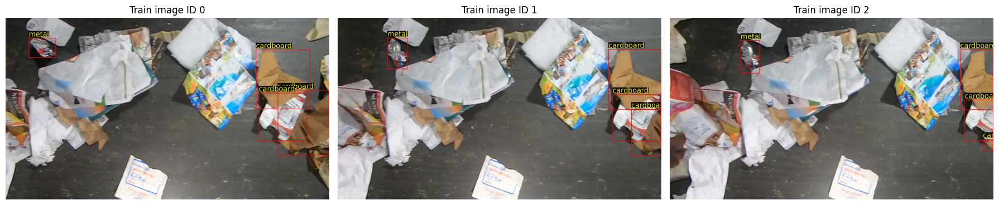

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for axis, image_id in zip(axes, sorted(image_paths['train'])[:3]):
    path = image_paths['train'][image_id]
    canvas = Image.open(path).convert('RGB')
    draw = ImageDraw.Draw(canvas)
    width, height = canvas.size
    for line in (DATA / 'train/labels' / f'{image_id}.txt').read_text().splitlines():
        cls, cx, cy, bw, bh = map(float, line.split())
        box = [(cx-bw/2)*width, (cy-bh/2)*height, (cx+bw/2)*width, (cy+bh/2)*height]
        draw.rectangle(box, outline='red', width=3)
        font = ImageFont.truetype(
        str(__import__('matplotlib').font_manager.findfont('DejaVu Sans')),
        size=max(18, int(width / 45)),
        )
        text = NAMES[int(cls)]
        tx = max(0, box[0])
        ty = max(0, box[1] - font.size - 6)

        text_box = draw.textbbox((tx, ty), text, font=font)
        draw.rectangle(text_box, fill='black')
        draw.text((tx, ty), text, font=font, fill='yellow')
    axis.imshow(canvas)
    axis.set_title(f'Train image ID {image_id}')
    axis.axis('off')
plt.tight_layout()
plt.savefig(REPORT / 'label_check.png', dpi=150)
plt.show()


## 6b. Hasil referensi dari paper
Nguyen D. Vo et al., *Empirical Study of Real-time One-Stage Object Detection
Methods on Recyclable Waste Dataset*, RIVF 2022, pp. 268–273.
[DOI: 10.1109/RIVF55975.2022.10013902](https://doi.org/10.1109/RIVF55975.2022.10013902).
Angka ditranskripsikan dari **Table I, halaman cetak 271 (halaman PDF ke-4)**
dan sudah diperiksa terhadap PDF pengguna. PDF tidak perlu diunggah oleh dosen.

Table I menulis YOLOv5; Section IV-B menjelaskan varian yang dilatih adalah
**YOLOv5s**. APm YOLOv4 dipertahankan **0.74** persis sebagaimana tercetak.
Baseline RetinaNet, Mask-RCNN, dan TridentNet juga dicatat terpisah.

Paper memakai Colab Pro Tesla P100, pretraining MS-COCO, dan 300 epoch;
YOLOv3/YOLOF memakai MMDetection 2.25.1. Notebook ini memakai YOLO11 Ultralytics,
default 300 epoch, dan GPU yang tersedia. Karena protokol berbeda, hasil gabungan
adalah **perbandingan dengan hasil terlapor**, bukan reproduksi terkontrol paper.
Mengganti EPOCHS menjadi 300 menyamakan jumlah epoch saja, bukan seluruh protokol.


In [8]:
PAPER_DOI = '10.1109/RIVF55975.2022.10013902'
PAPER_METRICS = ['AP', 'AP50', 'AP75', 'APs', 'APm', 'APl']
paper_results = pd.DataFrame([
    ['YOLOv3', 22.0, 34.1, 23.4, 1.6, 9.6, 23.6],
    ['YOLOv4', 22.4, 32.9, 24.5, 0.7, 0.74, 24.4],
    ['YOLOv5s', 25.3, 36.1, 27.6, 4.7, 14.7, 27.0],
    ['YOLOv7', 33.2, 44.3, 35.0, 5.9, 20.0, 35.6],
    ['YOLOF', 26.2, 41.5, 28.6, 1.4, 10.8, 28.6],
], columns=['Model'] + PAPER_METRICS)
paper_results['Source'] = 'Paper — Table I (reported)'
paper_results['Epochs'] = 300
paper_baselines = pd.DataFrame([
    ['RetinaNet', 21.0, 33.5, 22.2, 4.3, 9.5, 22.7],
    ['Mask-RCNN', 22.8, 34.9, 24.4, 4.6, 10.6, 25.8],
    ['TridentNet', 24.2, 36.3, 26.6, 4.8, 10.7, 26.1],
], columns=['Model'] + PAPER_METRICS)
paper_baselines['Source'] = 'Baseline reproduced in paper — Table I'
display(paper_results)
display(paper_baselines)
paper_results.to_csv(REPORT / 'paper_reference_table_I.csv', index=False)
paper_baselines.to_csv(REPORT / 'paper_baselines_table_I.csv', index=False)
paper_metadata = dict(title='Empirical Study of Real-time One-Stage Object Detection Methods on Recyclable Waste Dataset',
                      doi=PAPER_DOI, year=2022, table='I', printed_page=271,
                      pdf_page=4, epochs=300, gpu='Tesla P100',
                      pretrained='MS-COCO', yolov5_variant='YOLOv5s',
                      note='YOLOv4 APm=0.74 retained exactly as published')
(REPORT / 'paper_reference_metadata.json').write_text(json.dumps(paper_metadata, indent=2))


,Model,AP,AP50,AP75,APs,APm,APl,Source,Epochs
0,YOLOv3,22.0,34.1,23.4,1.6,9.60,23.6,Paper — Table I (reported),300
1,YOLOv4,22.4,32.9,24.5,0.7,0.74,24.4,Paper — Table I (reported),300
2,YOLOv5s,25.3,36.1,27.6,4.7,14.70,27.0,Paper — Table I (reported),300
3,YOLOv7,33.2,44.3,35.0,5.9,20.00,35.6,Paper — Table I (reported),300
4,YOLOF,26.2,41.5,28.6,1.4,10.80,28.6,Paper — Table I (reported),300


,Model,AP,AP50,AP75,APs,APm,APl,Source
0,RetinaNet,21.0,33.5,22.2,4.3,9.5,22.7,Baseline reproduced in paper — Table I
1,Mask-RCNN,22.8,34.9,24.4,4.6,10.6,25.8,Baseline reproduced in paper — Table I
2,TridentNet,24.2,36.3,26.6,4.8,10.7,26.1,Baseline reproduced in paper — Table I


381

## 7a. Lingkungan lama dan repository resmi
Python 3.10 + PyTorch 1.13.1/CUDA 11.7 disiapkan dalam virtual environment
terpisah melalui uv; kernel Colab modern tidak diturunkan versinya.
MMDetection 2.25.1 dan MMCV-full 1.7.0 memakai wheel CUDA siap pakai.
Repository YOLOv4/v7 dikunci commit, YOLOv5 tag v6.2, MMDetection tag v2.25.1.
Pure-PyTorch Mish bawaan repo YOLOv4 digunakan (tidak perlu kompilasi mish-cuda).
Patch kompatibilitas dan adapter disimpan terpisah; file asli UIT tetap ada.


In [9]:
"""Adapters embedded into Colab; upstream model architectures remain unchanged."""
import re
import sys
import time
from textwrap import dedent


def checked(command, cwd=None, log=None):
    command = list(map(str, command))
    print(' '.join(command), flush=True)
    environment = dict(os.environ, WANDB_MODE='disabled', WANDB_DISABLED='true')
    if log is None:
        subprocess.run(command, cwd=cwd, env=environment, check=True)
    else:
        with Path(log).open('a', encoding='utf-8') as output:
            process = subprocess.Popen(command, cwd=cwd, env=environment,
                                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                                       text=True, bufsize=1)
            try:
                for line in process.stdout:
                    output.write(line)
                    output.flush()
                    print(line, end='', flush=True)
                return_code = process.wait()
            except BaseException:
                process.terminate()
                process.wait()
                raise
            if return_code:
                raise subprocess.CalledProcessError(return_code, command)


def setup_legacy_environment(root, report):
    root, report = Path(root), Path(report)
    root.mkdir(parents=True, exist_ok=True)
    checked([sys.executable, '-m', 'pip', 'install', '-q', 'uv==0.9.5'])
    python = root / 'venv/bin/python'
    if not python.exists():
        checked([sys.executable, '-m', 'uv', 'venv', '--python', '3.10', '--seed', str(root / 'venv')])
    marker = root / 'venv/.dependencies_ready'
    if not marker.exists():
        checked([python, '-m', 'pip', 'install', 'torch==1.13.1+cu117',
                 'torchvision==0.14.1+cu117', '--extra-index-url', 'https://download.pytorch.org/whl/cu117'])
        checked([python, '-m', 'pip', 'install', 'numpy==1.23.5', 'Pillow==9.5.0',
                 'opencv-python==4.8.1.78', 'matplotlib==3.7.3', 'pandas==1.5.3',
                 'scipy==1.10.1', 'seaborn==0.12.2', 'protobuf==3.20.1',
                 'tensorboard==2.12.3', 'setuptools==69.5.1', 'yapf==0.40.1',
                 'pycocotools==2.0.7', 'PyYAML==6.0.2', 'requests==2.32.3',
                 'tqdm==4.67.1', 'psutil==6.1.0', 'thop==0.1.1.post2209072238',
                 'ipython==8.18.1', 'packaging==24.2', 'terminaltables==3.1.10'])
        checked([python, '-m', 'pip', 'install', '--only-binary=mmcv-full', 'mmcv-full==1.7.0',
                 '-f', 'https://download.openmmlab.com/mmcv/dist/cu117/torch1.13.0/index.html'])
        checked([python, '-m', 'pip', 'install', 'mmdet==2.25.1'])
        marker.write_text('python3.10 torch1.13.1 cu117 mmcv1.7.0 mmdet2.25.1')
    # Test CUDA ops before launching any multi-hour training job.
    checked([python, '-c', "import torch,mmcv,mmdet; from mmcv.ops import nms; "
             "assert torch.cuda.is_available(); "
             "nms(torch.tensor([[0.,0.,10.,10.]],device='cuda'),torch.ones(1,device='cuda'),0.5); "
             "print(torch.__version__,mmcv.__version__,mmdet.__version__,torch.cuda.get_device_name(0))"])
    return python


def checkout_upstream(destination, url, ref):
    destination = Path(destination)
    if not (destination / '.git').exists():
        destination.mkdir(parents=True, exist_ok=True)
        checked(['git', 'init', str(destination)])
        checked(['git', 'remote', 'add', 'origin', url], cwd=destination)
    head = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=destination,
                          text=True, capture_output=True)
    expected = subprocess.run(['git', 'rev-parse', ref], cwd=destination,
                              text=True, capture_output=True)
    if head.returncode or expected.returncode or head.stdout.strip() != expected.stdout.strip():
        checked(['git', 'fetch', '--depth', '1', 'origin', ref], cwd=destination)
        checked(['git', 'checkout', '--detach', 'FETCH_HEAD'], cwd=destination)
    return destination


def apply_legacy_compatibility(paths, seed, report):
    changes = []
    for name in ['YOLOv4', 'YOLOv7']:
        path = paths[name] / 'train.py'
        original = path.read_text()
        modified = re.sub(r'init_seeds\(\d+\s*\+\s*(?:rank|max\(rank,\s*0\))\)',
                          f'init_seeds({seed} + max(rank, 0))', original)
        if name == 'YOLOv4':
            # Preserve cfg from opt.yaml when resuming (upstream sets it to '').
            modified = modified.replace("opt.cfg, opt.weights, opt.resume = '', ckpt, True",
                                        'opt.weights, opt.resume = ckpt, True')
        if modified != original:
            path.write_text(modified)
        changes.append(dict(model=name, seed=seed,
                            resume_cfg_fix=(name == 'YOLOv4')))
    for name in ['YOLOv4', 'YOLOv5s', 'YOLOv7']:
        path = paths[name] / 'utils/loss.py'
        original = path.read_text()
        modified = re.sub(r'(g[ij]\.clamp_\(\s*0,\s*)gain\[(\d+)\](\s*-\s*1\s*\))',
                          r'\1int(gain[\2])\3', original)
        if modified != original:
            path.write_text(modified)
        changes.append(dict(model=name, integer_clamp_compatibility=(modified != original)))
    (Path(report) / 'compatibility_adapters.json').write_text(json.dumps(changes, indent=2))


def download_weight(url, target):
    import requests
    target = Path(target)
    if target.is_file() and target.stat().st_size > 1_000_000:
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    partial = target.with_suffix(target.suffix + '.part')
    with requests.get(url, stream=True, timeout=(30, 180)) as response:
        response.raise_for_status()
        with partial.open('wb') as output:
            for chunk in response.iter_content(8 * 1024 * 1024):
                if chunk:
                    output.write(chunk)
    assert partial.stat().st_size > 1_000_000, 'Bobot yang diunduh terlalu kecil.'
    partial.replace(target)
    return target


def write_adapter(report, name, source):
    folder = Path(report) / 'adapters'
    folder.mkdir(parents=True, exist_ok=True)
    target = folder / name
    target.write_text(dedent(source), encoding='utf-8')
    return target


def train_legacy_model(name, python, paths, reference, data, raw, data_yaml,
                       runs, report, epochs, batch, seed, resume):
    # Persistent run folder makes interrupted checkpoints available next session.
    run = Path(runs) / f'{name}_e{epochs}_b{batch}_seed{seed}'
    if EXECUTION_MODE == 'evaluate':
        done = run / 'completed.json'
        if not done.is_file():
            raise FileNotFoundError(f"Metadata checkpoint belum tersedia: {done}. Pulihkan hasil eksperimen ke RUNS atau pilih mode train.")
        status = json.loads(done.read_text())
        saved = Path(status['best'])
        best = saved if saved.is_file() else run / 'weights' / saved.name
        if not best.is_file():
            best = run / saved.name
        if not best.is_file():
            raise FileNotFoundError(f"Checkpoint tidak ditemukan: {saved}")
        settings = dict(status['settings'])
        if settings.get('cfg_reference'):
            settings['cfg_reference'] = str(Path(reference) / 'config' / name / Path(settings['cfg_reference']).name)
        return best, status['training_hours'], settings
    run.mkdir(parents=True, exist_ok=True)
    configs = {'YOLOv3': 'config/YOLOv3/yolov3_darknet53.py',
               'YOLOF': 'config/YOLOF/yolof_voc.py',
               'YOLOv4': 'config/YOLOv4/yolov4.cfg',
               'YOLOv7': 'config/YOLOv7/yolov7.yaml'}
    reference_config = str(Path(reference) / configs[name]) if name in configs else None
    repo_name = 'mmdetection' if name in ('YOLOv3', 'YOLOF') else name
    repo = paths[repo_name]
    upstream_commit = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=repo, text=True).strip()
    settings = dict(model=name, epochs=epochs, batch=batch, seed=seed,
                    cfg_reference=reference_config, upstream_commit=upstream_commit,
                    config_sha256=hashlib.sha256(Path(reference_config).read_bytes()).hexdigest() if reference_config else None,
                    input_size={'YOLOv3': 608, 'YOLOF': [1333, 800],
                                'YOLOv4': 448, 'YOLOv5s': 640, 'YOLOv7': 640}[name])
    signature = hashlib.sha256(json.dumps(settings, sort_keys=True).encode()).hexdigest()
    previous = run / 'training_signature.json'
    if previous.exists():
        assert json.loads(previous.read_text())['signature'] == signature, 'Konfigurasi berubah: gunakan tag eksperimen baru.'
    previous.write_text(json.dumps(dict(signature=signature, settings=settings), indent=2))
    done = run / 'completed.json'
    if done.exists():
        status = json.loads(done.read_text())
        assert status['signature'] == signature
        best = Path(status['best'])
        assert best.is_file()
        print('Training sudah selesai; gunakan checkpoint:', best)
        return best, status['training_hours'], status['settings']

    if name in ('YOLOv3', 'YOLOF'):
        adapter = write_adapter(report, 'train_mmdet.py', MMDET_TRAIN)
        config = run / 'effective_config.py'
        checkpoints = list(run.glob('epoch_*.pth'))
        last = max(checkpoints, key=lambda p: int(p.stem.split('_')[-1])) if checkpoints else run / 'latest.pth'
        command = [python, adapter, name, reference_config, data, epochs, batch,
                   seed, run, config, str(repo), str(last) if resume and last.exists() else '']
    else:
        weights_root = Path(runs).parent / 'pretrained'
        weights_root.mkdir(exist_ok=True)
        if name == 'YOLOv4':
            darknet_weight = download_weight(
                'https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov4.weights',
                weights_root / 'yolov4.weights')
            weight = weights_root / 'yolov4_coco_initializer.pt'
            if not weight.exists():
                adapter = write_adapter(report, 'convert_yolov4_pretrained.py', V4_INITIALIZER)
                checked([python, adapter, reference_config, darknet_weight, weight, repo], cwd=repo)
        elif name == 'YOLOv5s':
            weight = download_weight('https://github.com/ultralytics/yolov5/releases/download/v6.2/yolov5s.pt',
                                     weights_root / 'yolov5s.pt')
        else:
            weight = download_weight('https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt',
                                     weights_root / 'yolov7.pt')
        settings['pretrained'] = str(weight)
        last = run / 'weights/last.pt'
        if resume and last.exists():
            command = [python, repo / 'train.py', '--resume', last]
        else:
            command = [python, repo / 'train.py', '--weights', weight, '--data', data_yaml,
                       '--epochs', epochs, '--batch-size', batch, '--img-size', settings['input_size'],
                       '--device', '0', '--workers', '2', '--project', runs, '--name', run.name, '--exist-ok']
            if name in ('YOLOv4', 'YOLOv7'):
                command += ['--cfg', reference_config]
            if name == 'YOLOv7':
                command += ['--hyp', repo / 'data/hyp.scratch.p5.yaml']
            if name == 'YOLOv5s':
                command += ['--seed', seed, '--patience', '0']
    start = time.perf_counter()
    checked(command, cwd=repo, log=run / 'console.log')
    elapsed = (time.perf_counter() - start) / 3600
    if name in ('YOLOv3', 'YOLOF'):
        candidates = list(run.glob('best_bbox_mAP*.pth'))
        assert candidates, 'Best validation checkpoint tidak ditemukan.'
        best = max(candidates, key=lambda p: p.stat().st_mtime)
        settings['effective_config'] = str(run / 'effective_config.py')
    else:
        best = run / 'weights/best.pt'
    assert best.is_file(), f'Training tidak menghasilkan best checkpoint: {best}'
    done.write_text(json.dumps(dict(signature=signature, best=str(best),
                                   training_hours=elapsed, settings=settings), indent=2))
    return best, elapsed, settings


MMDET_TRAIN = r'''
import sys, re
from pathlib import Path
name, reference, data, epochs, batch, seed, work, effective, repo, last = sys.argv[1:]
sys.path.insert(0, repo)
from mmcv import Config
from mmdet.apis import train_detector, set_random_seed
from mmdet.datasets import build_dataset
from mmdet.models import build_detector
cfg = Config.fromfile(reference)
classes = ('rigid_plastic', 'cardboard', 'metal', 'soft_plastic')
for split in ['train', 'val', 'test']:
    cfg.data[split].ann_file = str(Path(data) / split / 'ground_truth.json')
    cfg.data[split].img_prefix = str(Path(data) / split / 'images')
    cfg.data[split].classes = classes
cfg.data.samples_per_gpu = int(batch)
cfg.data.workers_per_gpu = 2
cfg.runner.max_epochs = int(epochs)
cfg.total_epochs = int(epochs)
cfg.work_dir = work
cfg.gpu_ids = [0]
cfg.device = 'cuda'
cfg.seed = int(seed)
cfg.checkpoint_config = dict(interval=1, max_keep_ckpts=2, create_symlink=False)
cfg.evaluation = dict(interval=1, metric='bbox', save_best='bbox_mAP', rule='greater')
cfg.resume_from = last or None
if name == 'YOLOF':
    readme = (Path(repo) / 'configs/yolof/README.md').read_text()
    urls = re.findall(r'https://download[.]openmmlab[.]com/[^\s)]+[.]pth', readme)
    candidates = [u for u in urls if 'yolof_r50_c5' in u and '1x_coco' in u]
    assert candidates, 'Checkpoint COCO resmi YOLOF tidak ditemukan.'
    cfg.load_from = candidates[0]
cfg.dump(effective)
set_random_seed(int(seed), deterministic=True)
model = build_detector(cfg.model, train_cfg=cfg.get('train_cfg'), test_cfg=cfg.get('test_cfg'))
model.init_weights()
datasets = [build_dataset(cfg.data.train)]
model.CLASSES = classes
cfg.checkpoint_config.meta = dict(CLASSES=classes)
train_detector(model, datasets, cfg, distributed=False, validate=True,
               timestamp=__import__('time').strftime('%Y%m%d_%H%M%S'),
               meta=dict(seed=int(seed), config=cfg.pretty_text, CLASSES=classes))
'''


V4_INITIALIZER = r'''
import sys
reference, weights, destination, repo = sys.argv[1:]
sys.path.insert(0, repo)
import torch
from models.models import Darknet, load_darknet_weights
cfg = Path(destination).with_suffix('.cfg')
cfg.write_text(Path(reference).read_text().replace('classes=4', 'classes=80').replace('filters=27', 'filters=255'))
model = Darknet(str(cfg))
load_darknet_weights(model, weights)
checkpoint = dict(model=model.state_dict(), optimizer=None, epoch=-1,
                  training_results=None, best_fitness=0.0)
for suffix in ('p', 'r', 'ap50', 'ap', 'f'):
    checkpoint['best_fitness_' + suffix] = 0.0
torch.save(checkpoint, destination)
print('COCO weights loaded and converted:', destination)
'''


def export_legacy_predictions(name, weight, python, paths, settings, data,
                               gt, output, conf, nms_iou, max_det):
    repo = paths['mmdetection' if name in ('YOLOv3', 'YOLOF') else name]
    adapter = write_adapter(Path(output).parent, 'predict_legacy.py', LEGACY_PREDICT)
    config = settings.get('effective_config') or settings.get('cfg_reference') or ''
    checked([python, adapter, name, weight, repo, config, data, gt, output,
             conf, nms_iou, max_det, json.dumps(settings['input_size'])], cwd=repo)


LEGACY_PREDICT = r'''
import sys, json, inspect
from pathlib import Path
name, weight, repo, config, data, gt_path, output, conf, nms_iou, max_det, size = sys.argv[1:]
sys.path.insert(0, repo)
import numpy as np
import torch
import cv2
from tqdm import tqdm
conf, nms_iou, max_det = float(conf), float(nms_iou), int(max_det)
size = json.loads(size)
truth = json.loads(Path(gt_path).read_text())
names = ['rigid_plastic', 'cardboard', 'metal', 'soft_plastic']
by_name = {c['name']: c['id'] for c in truth['categories']}
category_ids = [by_name[n] for n in names]
images_folder = Path(data) / 'test/images'
image_files = {int(p.stem): p for p in images_folder.iterdir() if p.suffix.lower() in {'.png','.jpg','.jpeg'}}
predictions = []
device = torch.device('cuda:0')
if name in ('YOLOv3', 'YOLOF'):
    from mmcv import Config
    from mmdet.apis import init_detector, inference_detector
    cfg = Config.fromfile(config)
    cfg.model.test_cfg.score_thr = conf
    cfg.model.test_cfg.nms.iou_threshold = nms_iou
    cfg.model.test_cfg.max_per_img = max_det
    if name == 'YOLOv3':
        cfg.model.test_cfg.conf_thr = conf
    detector = init_detector(cfg, weight, device='cuda:0')
    for image in tqdm(truth['images'], desc=name):
        result = inference_detector(detector, str(image_files[image['id']]))
        if isinstance(result, tuple):
            result = result[0]
        for cls, boxes in enumerate(result):
            for x1,y1,x2,y2,score in boxes:
                predictions.append(dict(image_id=image['id'], category_id=category_ids[cls],
                                         bbox=[float(x1),float(y1),float(x2-x1),float(y2-y1)], score=float(score)))
else:
    from utils.general import non_max_suppression, scale_coords
    if name == 'YOLOv5s':
        from utils.augmentations import letterbox
    else:
        from utils.datasets import letterbox
    if name == 'YOLOv4':
        from models.models import Darknet
        detector = Darknet(config).to(device)
        checkpoint = torch.load(weight, map_location=device)
        detector.load_state_dict(checkpoint['model'])
        stride = 64
    else:
        from models.experimental import attempt_load
        params = inspect.signature(attempt_load).parameters
        kwargs = {'map_location': device} if 'map_location' in params else {'device': device}
        detector = attempt_load(weight, **kwargs)
        stride = int(detector.stride.max())
    detector.float().eval()
    for image in tqdm(truth['images'], desc=name):
        original = cv2.imread(str(image_files[image['id']]))
        assert original is not None
        letterbox_kwargs = dict(new_shape=(size, size), auto=False)
        if 'stride' in inspect.signature(letterbox).parameters:
            letterbox_kwargs['stride'] = stride
        padded = letterbox(original, **letterbox_kwargs)[0]
        rgb = np.ascontiguousarray(padded[:,:,::-1].transpose(2,0,1))
        tensor = torch.from_numpy(rgb).to(device).float().unsqueeze(0) / 255.0
        with torch.no_grad():
            raw_prediction = detector(tensor)[0]
        nms_params = inspect.signature(non_max_suppression).parameters
        kwargs = {}
        if 'max_det' in nms_params:
            kwargs['max_det'] = max_det
        if 'multi_label' in nms_params:
            kwargs['multi_label'] = True
        detection = non_max_suppression(raw_prediction, conf, nms_iou, **kwargs)[0]
        if detection is not None and len(detection):
            detection = detection[:max_det]
            detection[:, :4] = scale_coords(tensor.shape[2:], detection[:, :4], original.shape)
            for x1,y1,x2,y2,score,cls in detection.cpu().tolist():
                predictions.append(dict(image_id=image['id'], category_id=category_ids[int(cls)],
                                         bbox=[x1,y1,x2-x1,y2-y1], score=score))
Path(output).write_text(json.dumps(predictions))
print('Saved predictions:', output, len(predictions))
'''


LEGACY = BASE / 'legacy'
LEGACY.mkdir(exist_ok=True)
LEGACY_PY = setup_legacy_environment(LEGACY, REPORT)
upstream_commits = {
    'YOLOv4': '6e88dc21813e614c9848a2767fd0bac13d26fd51',
    'YOLOv7': 'a207844b1ce82d204ab36d87d496728d3d2348e7',
    'YOLOv5s': 'v6.2', 'mmdetection': 'v2.25.1'}
upstream_urls = {
    'YOLOv4': 'https://github.com/WongKinYiu/PyTorch_YOLOv4.git',
    'YOLOv7': 'https://github.com/WongKinYiu/yolov7.git',
    'YOLOv5s': 'https://github.com/ultralytics/yolov5.git',
    'mmdetection': 'https://github.com/open-mmlab/mmdetection.git'}
upstream_paths = {}
for name, url in upstream_urls.items():
    upstream_paths[name] = checkout_upstream(LEGACY / name, url, upstream_commits[name])
apply_legacy_compatibility(upstream_paths, SEED, REPORT)
# Label dari tahap konversi tervalidasi dipertahankan.
subprocess.run([str(LEGACY_PY), '-m', 'pip', 'freeze'], check=True,
               stdout=(REPORT / 'requirements_legacy.txt').open('w'))


/usr/bin/python3 -m pip install -q uv==0.9.5
/usr/bin/python3 -m uv venv --python 3.10 --seed /content/zerowaste_experiment/legacy/venv
/content/zerowaste_experiment/legacy/venv/bin/python -m pip install torch==1.13.1+cu117 torchvision==0.14.1+cu117 --extra-index-url https://download.pytorch.org/whl/cu117
/content/zerowaste_experiment/legacy/venv/bin/python -m pip install numpy==1.23.5 Pillow==9.5.0 opencv-python==4.8.1.78 matplotlib==3.7.3 pandas==1.5.3 scipy==1.10.1 seaborn==0.12.2 protobuf==3.20.1 tensorboard==2.12.3 setuptools==69.5.1 yapf==0.40.1 pycocotools==2.0.7 PyYAML==6.0.2 requests==2.32.3 tqdm==4.67.1 psutil==6.1.0 thop==0.1.1.post2209072238 ipython==8.18.1 packaging==24.2 terminaltables==3.1.10
/content/zerowaste_experiment/legacy/venv/bin/python -m pip install --only-binary=mmcv-full mmcv-full==1.7.0 -f https://download.openmmlab.com/mmcv/dist/cu117/torch1.13.0/index.html
/content/zerowaste_experiment/legacy/venv/bin/python -m pip install mmdet==2.25.1
/content/zerowaste_

CompletedProcess(args=['/content/zerowaste_experiment/legacy/venv/bin/python', '-m', 'pip', 'freeze'], returncode=0)

In [10]:
# Adaptasi kompatibilitas upstream; aman dijalankan berulang.
def patch_source(path, old, new):
    path = Path(path)
    code = path.read_text()
    if new in code:
        return
    if old not in code:
        raise RuntimeError(f"Versi source tidak cocok untuk patch: {path}")
    updated = code.replace(old, new, 1)
    compile(updated, str(path), 'exec')
    path.write_text(updated)

patch_source(
    Path(upstream_paths['YOLOv4']) / 'utils/loss.py',
    'a, t = at[j], t.repeat(na, 1, 1)[j]',
    'a, t = at.to(t.device)[j], t.repeat(na, 1, 1)[j]',
)
header = 'def output_to_target(output, width, height):'
patch_source(
    Path(upstream_paths['YOLOv4']) / 'utils/plots.py',
    header, header + '\n    output = [o.detach().cpu() for o in output]',
)
patch_source(
    Path(upstream_paths['YOLOv7']) / 'utils/datasets.py',
    ".with_suffix('.cache')", ".with_suffix('.cache.yolov7')",
)
print('Compatibilitas loss, plotting, dan cache siap.')


Compatibilitas loss, plotting, dan cache siap.


## 7b. Training ulang YOLOv3/v4/v5s/v7/YOLOF
Konfigurasi model diambil dari GitHub UIT, path data diganti ke dataset lokal.
Ukuran input dan hyperparameter bawaan tiap repo dipertahankan. Batch dan epoch
diatur di awal. Bobot YOLOF awal diganti dari path Drive penulis yang tidak
tersedia menjadi checkpoint COCO resmi model yang sama. YOLOv4 memakai
bobot COCO Darknet resmi yang dikonversi ke initializer PyTorch agar benar-benar
dimuat oleh train.py upstream. Tidak ada fallback diam-diam ke training acak.
Pengaturan baru dan selisih terhadap paper harus dicantumkan dalam laporan.


In [11]:
import traceback

RESUME = True
REPORT.mkdir(parents=True, exist_ok=True)

legacy_weights = globals().get("legacy_weights", {})
legacy_hours = globals().get("legacy_hours", {})
legacy_settings = globals().get("legacy_settings", {})
legacy_failures = {}


def prepare_legacy_model(model_name):
    global MMDET_TRAIN

    if model_name == "YOLOv5s":
        # Gunakan font bawaan Matplotlib di environment training.
        output = subprocess.check_output(
            [
                str(LEGACY_PY),
                "-c",
                "from matplotlib.font_manager import findfont; "
                "print(findfont('DejaVu Sans'))",
            ],
            text=True,
        )
        font = Path(output.strip().splitlines()[-1])
        if not font.is_file():
            raise FileNotFoundError(f"Font tidak ditemukan: {font}")

        font_dir = Path("/root/.config/Ultralytics")
        font_dir.mkdir(parents=True, exist_ok=True)
        for font_name in ("Arial.ttf", "Arial.Unicode.ttf"):
            shutil.copyfile(font, font_dir / font_name)

        print("Font YOLOv5 siap.", flush=True)

    elif model_name == "YOLOv7":
        # Jangan ubah huruf besar/kecil path Google Drive.
        p = Path(upstream_paths["YOLOv7"]) / "utils/google_utils.py"
        code = p.read_text()
        old = """file = Path(str(file).strip().replace("'", '').lower())"""
        new = """file = Path(str(file).strip().replace("'", ''))"""

        if old in code:
            p.write_text(code.replace(old, new, 1))
        elif new not in code:
            raise RuntimeError("Kode download YOLOv7 berbeda; perlu diperiksa.")

        print("Path checkpoint YOLOv7 diperbaiki.", flush=True)

    elif model_name == "YOLOF":
        # Runner menulis adapter dari template ini setiap kali dijalankan.
        old = "'yolof_r50_c5_1x_coco' in u"
        new = "'yolof_r50_c5' in u and '1x_coco' in u"

        if old in MMDET_TRAIN:
            MMDET_TRAIN = MMDET_TRAIN.replace(old, new)
        elif new not in MMDET_TRAIN:
            raise RuntimeError("Template adapter YOLOF berbeda; perlu diperiksa.")

        print("Filter checkpoint YOLOF diperbaiki.", flush=True)


for model_name in LEGACY_MODELS:
    print(f"\n{'=' * 50}\nTraining: {model_name}", flush=True)

    try:
        # Model selesai tidak perlu dipatch atau dilatih lagi.
        completed = (
            Path(RUNS)
            / f"{model_name}_e{EPOCHS}_b{BATCH}_seed{SEED}"
            / "completed.json"
        )
        if EXECUTION_MODE == 'train' and not completed.exists():
            prepare_legacy_model(model_name)

        best, hours, settings = train_legacy_model(
            model_name, LEGACY_PY, upstream_paths, REFERENCE, DATA, RAW,
            LEGACY_DATA_YAML, RUNS, REPORT,
            EPOCHS, BATCH, SEED, RESUME,
        )

        legacy_weights[model_name] = best
        legacy_hours[model_name] = hours
        legacy_settings[model_name] = settings

        (REPORT / "legacy_training_settings.json").write_text(
            json.dumps(legacy_settings, indent=2)
        )
        print(f"{model_name} selesai: {best}", flush=True)

    except Exception:
        error_log = traceback.format_exc()
        legacy_failures[model_name] = error_log
        (REPORT / f"{model_name}_training_error.txt").write_text(error_log)
        print(error_log, flush=True)
        print(f"{model_name} gagal; lanjut ke model berikutnya.", flush=True)

    (REPORT / "legacy_training_failures.json").write_text(
        json.dumps(legacy_failures, indent=2)
    )

print("\nModel tersedia:", list(legacy_weights))
print("Model gagal pada percobaan ini:", list(legacy_failures))


if legacy_failures:
    raise RuntimeError('Model belum lengkap. Periksa legacy_training_failures.json; evaluasi tidak diteruskan dengan hasil parsial.')

def evaluate_saved_legacy(model_name):
    if model_name not in legacy_weights:
        print(f"Lewati evaluasi {model_name}: checkpoint belum tersedia.")
        return None

    prediction_file = REPORT / f"{model_name}_predictions.json"
    export_legacy_predictions(
        model_name, legacy_weights[model_name],
        LEGACY_PY, upstream_paths, legacy_settings[model_name],
        DATA, splits["test"], prediction_file,
        EVAL_CONF, NMS_IOU, MAX_DET,
    )

    predictions = json.loads(prediction_file.read_text())
    truth = COCO(str(splits["test"]))

    if predictions:
        detected = truth.loadRes(predictions)
    else:
        detected = COCO()
        detected.dataset = dict(
            images=truth.dataset["images"],
            categories=truth.dataset["categories"],
            annotations=[],
        )
        detected.createIndex()

    evaluator = COCOeval(truth, detected, "bbox")
    evaluator.params.imgIds = sorted(image_paths["test"])
    evaluator.params.catIds = list(class_to_category["test"].values())
    evaluator.params.maxDets = [1, 10, MAX_DET]
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    stats = evaluator.stats.tolist()
    (REPORT / f"{model_name}_coco_stats.json").write_text(
        json.dumps(stats)
    )

    return dict(
        Model=model_name,
        **{
            name: value * 100 if value >= 0 else np.nan
            for name, value in zip(METRICS, stats[:6])
        },
        Training_hours=legacy_hours[model_name],
    )


Training: YOLOv3
YOLOv3 selesai: /content/drive/MyDrive/ZeroWaste/experiments/paper_plus_yolo11_v1/runs/YOLOv3_e30_b2_seed42/best_bbox_mAP_epoch_16.pth

Training: YOLOv4
YOLOv4 selesai: /content/drive/MyDrive/ZeroWaste/experiments/paper_plus_yolo11_v1/runs/YOLOv4_e30_b2_seed42/weights/best.pt

Training: YOLOv5s
YOLOv5s selesai: /content/drive/MyDrive/ZeroWaste/experiments/paper_plus_yolo11_v1/runs/YOLOv5s_e30_b2_seed42/weights/best.pt

Training: YOLOv7
YOLOv7 selesai: /content/drive/MyDrive/ZeroWaste/experiments/paper_plus_yolo11_v1/runs/YOLOv7_e30_b2_seed42/weights/best.pt

Training: YOLOF
YOLOF selesai: /content/drive/MyDrive/ZeroWaste/experiments/paper_plus_yolo11_v1/runs/YOLOF_e30_b2_seed42/best_bbox_mAP_epoch_8.pth

Model tersedia: ['YOLOv3', 'YOLOv4', 'YOLOv5s', 'YOLOv7', 'YOLOF']
Model gagal pada percobaan ini: []


## 7c. Training YOLO11n dan YOLO11x (tambahan)
Model baru memakai Ultralytics. Checkpoint ditulis langsung ke Drive. Jika
konfigurasi sama sudah selesai, best.pt digunakan kembali; jika belum selesai
dan last.pt tersedia, training dilanjutkan. Untuk memulai ulang gunakan tag baru.


In [12]:
COMMON = dict(data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH,
              device=0, workers=2, seed=SEED, deterministic=True,
              optimizer='SGD', lr0=0.01, lrf=0.01, momentum=0.937,
              weight_decay=0.0005, warmup_epochs=3.0,
              patience=0, amp=True, cache=False, pretrained=True,
              mosaic=1.0, close_mosaic=min(10, EPOCHS), mixup=0.0,
              fliplr=0.5, flipud=0.0, degrees=0.0, translate=0.1, scale=0.5,
              hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, plots=True, save=True,
              project=str(RUNS), exist_ok=True, save_period=-1)
manifest = dict(environment=environment, models=LEGACY_MODELS + MODELS, training=COMMON,
                paper_reference=paper_metadata,
                github_repo=REPO, github_commit=REPO_COMMIT,
                dataset_url=URL, dataset_md5=EXPECTED_MD5,
                category_mapping=class_to_category,
                evaluation=dict(split='test', conf=EVAL_CONF, nms_iou=NMS_IOU,
                                max_det=MAX_DET, evaluator='pycocotools.COCOeval'))
(REPORT / 'experiment_manifest.json').write_text(json.dumps(manifest, indent=2))
best_weights = dict(legacy_weights)
training_hours = dict(legacy_hours)
for model_name in MODELS:
    set_seed()
    run_name = f'{model_name}_e{EPOCHS}_img{IMG_SIZE}_b{BATCH}_seed{SEED}'
    run_dir = RUNS / run_name
    done = run_dir / 'completed.json'
    signature = hashlib.sha256(json.dumps(COMMON, sort_keys=True).encode()).hexdigest()
    if EXECUTION_MODE == 'evaluate':
        best = run_dir / 'weights/best.pt'
        if not best.is_file() or not done.is_file():
            raise FileNotFoundError(f"Checkpoint/metadata belum tersedia di {run_dir}; pulihkan hasil atau pilih mode train.")
        status = json.loads(done.read_text())
        best_weights[model_name] = best
        training_hours[model_name] = status['training_hours']
        continue
    if done.is_file():
        status = json.loads(done.read_text())
        assert status['signature'] == signature, 'Konfigurasi berubah; gunakan EXPERIMENT_TAG baru.'
        best_weights[model_name] = run_dir / 'weights/best.pt'
        assert best_weights[model_name].is_file()
        training_hours[model_name] = status['training_hours']
        print('Training sudah selesai; gunakan:', best_weights[model_name])
        continue
    previous = run_dir / 'training_signature.json'
    if previous.exists():
        assert json.loads(previous.read_text())['signature'] == signature, 'Gunakan tag baru untuk konfigurasi berbeda.'
    run_dir.mkdir(parents=True, exist_ok=True)
    previous.write_text(json.dumps(dict(signature=signature)))
    last = run_dir / 'weights/last.pt'
    detector = YOLO(str(last)) if RESUME and last.exists() else YOLO(f'{model_name}.pt')
    start = time.perf_counter()
    if RESUME and last.exists():
        detector.train(resume=True)
    else:
        detector.train(**COMMON, name=run_name)
    training_hours[model_name] = (time.perf_counter() - start) / 3600
    best = Path(detector.trainer.save_dir) / 'weights/best.pt'
    assert best.is_file(), f'Checkpoint belum tersedia: {best}'
    best_weights[model_name] = best
    done.write_text(json.dumps(dict(signature=signature, training_hours=training_hours[model_name])))
    del detector
    gc.collect()
    torch.cuda.empty_cache()
manifest['legacy_settings'] = legacy_settings
manifest['upstream_commits'] = upstream_commits
manifest['training_hours'] = training_hours
manifest['best_weights'] = {k: str(v) for k, v in best_weights.items()}
(REPORT / 'experiment_manifest.json').write_text(json.dumps(manifest, indent=2))


6114

## 8. Evaluasi resmi COCO pada test set
Prediksi memakai koordinat piksel gambar asli (`xyxy` → `xywh`). Kelas YOLO dipetakan
kembali ke ID kategori JSON; gambar dipetakan ke ID COCO asli. Prediksi diproses
dalam batch kecil supaya tidak memuat seluruh test set ke RAM.

COCOeval menggunakan IoU 0.50:0.05:0.95, maxDets [1,10,100], serta area small,
medium, large. Ground truth mempertahankan `area` anotasi asli (jika tidak tersedia,
menggunakan luas bbox). APs/APm/APl memakai batas area COCO 32² dan 96² piksel.
Metrik dalam persen; -1 dari COCO dilaporkan sebagai NaN (tidak tersedia), bukan 0.
Hasil ini memakai definisi metrik yang sama dengan tabel referensi, tetapi belum
tentu mereproduksi protokol training dan pre/postprocessing penelitian tersebut.


In [13]:
METRICS = ['AP', 'AP50', 'AP75', 'APs', 'APm', 'APl']

def evaluate_coco(model_name, weight):
    detector = YOLO(str(weight))
    assert [detector.names[i] for i in range(len(NAMES))] == NAMES
    predictions = []
    ids = sorted(image_paths['test'])
    for offset in tqdm(range(0, len(ids), BATCH), desc=f'Evaluasi {model_name}'):
        batch_ids = ids[offset:offset+BATCH]
        sources = [str(image_paths['test'][i]) for i in batch_ids]
        results = detector.predict(source=sources, imgsz=IMG_SIZE, device=0,
                                   conf=EVAL_CONF, iou=NMS_IOU, max_det=MAX_DET,
                                   augment=False, half=False, verbose=False)
        assert len(results) == len(batch_ids)
        for image_id, result in zip(batch_ids, results):
            boxes = result.boxes
            for xyxy, score, cls in zip(boxes.xyxy.cpu().tolist(),
                                        boxes.conf.cpu().tolist(), boxes.cls.cpu().tolist()):
                x1, y1, x2, y2 = xyxy
                predictions.append(dict(image_id=image_id,
                    category_id=class_to_category['test'][int(cls)],
                    bbox=[x1, y1, x2-x1, y2-y1], score=score))
    (REPORT / f'{model_name}_predictions.json').write_text(json.dumps(predictions))
    truth = COCO(str(splits['test']))
    if predictions:
        detected = truth.loadRes(predictions)
    else:
        # loadRes([]) crashes in COCO API; construct an empty result dataset.
        detected = COCO()
        detected.dataset = dict(images=truth.dataset['images'],
                                categories=truth.dataset['categories'], annotations=[])
        detected.createIndex()
    evaluator = COCOeval(truth, detected, iouType='bbox')
    evaluator.params.imgIds = ids
    evaluator.params.catIds = list(class_to_category['test'].values())
    evaluator.params.maxDets = [1, 10, MAX_DET]
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    row = dict(Model=model_name, **{name: float(value*100) if value >= 0 else np.nan
                                    for name, value in zip(METRICS, evaluator.stats[:6])})
    row['Parameters_M'] = sum(p.numel() for p in detector.model.parameters()) / 1e6
    row['Training_hours'] = training_hours[model_name]
    (REPORT / f'{model_name}_coco_stats.json').write_text(json.dumps(evaluator.stats.tolist()))
    del detector
    gc.collect()
    torch.cuda.empty_cache()
    return row

rows = []
for model_name in MODELS:
    rows.append(evaluate_coco(model_name, best_weights[model_name]))
    pd.DataFrame(rows).to_csv(REPORT / 'comparison.csv', index=False)
comparison = pd.DataFrame(rows).set_index('Model')
display(comparison.round(3))


Evaluasi yolo11n:   0%|          | 0/465 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.11s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.83s).
Accumulating evaluation results...
DONE (t=0.76s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.240
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.341
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.258
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.021
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.149
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.257
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.241
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.454
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

Evaluasi yolo11x:   0%|          | 0/465 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.35s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=4.72s).
Accumulating evaluation results...
DONE (t=0.66s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.331
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.441
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.357
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.048
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.361
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.291
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.527
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

,AP,AP50,AP75,APs,APm,APl,Parameters_M,Training_hours
Model,,,,,,,,
yolo11n,23.950,34.129,25.767,2.079,14.876,25.725,2.583,1.067
yolo11x,33.142,44.086,35.654,4.764,15.057,36.114,56.832,1.814


In [14]:
our_rows = []
evaluation_errors = {}

for model_name in LEGACY_MODELS:
    stats_file = REPORT / f"{model_name}_coco_stats.json"

    try:
        if stats_file.exists():
            stats = json.loads(stats_file.read_text())
            row = dict(
                Model=model_name,
                **{
                    metric: value * 100 if value >= 0 else np.nan
                    for metric, value in zip(METRICS, stats[:6])
                },
            )
        else:
            print(f"Evaluasi test set: {model_name}", flush=True)
            row = evaluate_saved_legacy(model_name)
            if row is None:
                raise RuntimeError("Checkpoint model belum tersedia.")

        row.update(
            Source="Eksperimen kita — test set",
            Epochs=EPOCHS,
        )
        our_rows.append(row)

    except Exception:
        evaluation_errors[model_name] = traceback.format_exc()
        print(evaluation_errors[model_name])

# Tambahkan hasil YOLO11 yang sudah dievaluasi.
for model_name in ["yolo11n", "yolo11x"]:
    stats_file = REPORT / f"{model_name}_coco_stats.json"

    if stats_file.exists():
        stats = json.loads(stats_file.read_text())
        our_rows.append(dict(
            Model=model_name,
            Source="Eksperimen kita — test set",
            Epochs=EPOCHS,
            **{
                metric: value * 100 if value >= 0 else np.nan
                for metric, value in zip(METRICS, stats[:6])
            },
        ))
    elif model_name in comparison.index:
        row = comparison.loc[model_name].to_dict()
        row["Model"] = model_name
        row["Epochs"] = EPOCHS
        row["Source"] = "Eksperimen kita — test set"
        our_rows.append(row)

columns = ["Model", "Source", "Epochs", *METRICS]
our_30_results = pd.DataFrame(our_rows).reindex(columns=columns)

print("\nHASIL TRAINING KITA:")
display(our_30_results.round(3))

comparison_30_vs_paper = pd.concat(
    [paper_results.reindex(columns=columns), our_30_results],
    ignore_index=True,
)
comparison_30_vs_paper = comparison_30_vs_paper.sort_values(
    ["Model", "Epochs"]
)

print("\nPERBANDINGAN DENGAN PAPER:")
display(comparison_30_vs_paper.round(3))

our_30_results.to_csv(
    REPORT / "our_training_results.csv", index=False
)
comparison_30_vs_paper.to_csv(
    REPORT / "our_results_vs_paper.csv", index=False
)

print("Model gagal dievaluasi:", list(evaluation_errors))
if evaluation_errors:
    raise RuntimeError('Evaluasi belum lengkap; periksa log sebelum membuat tabel/visualisasi.')



HASIL TRAINING KITA:


,Model,Source,Epochs,AP,AP50,AP75,APs,APm,APl
0,YOLOv3,Eksperimen kita — test set,30,16.244,30.569,15.361,0.163,11.431,17.405
1,YOLOv4,Eksperimen kita — test set,30,23.245,34.735,25.596,0.545,16.969,24.543
2,YOLOv5s,Eksperimen kita — test set,30,27.248,39.366,29.929,1.434,14.092,29.310
3,YOLOv7,Eksperimen kita — test set,30,34.676,47.300,37.328,4.021,20.311,37.556
4,YOLOF,Eksperimen kita — test set,30,30.909,44.716,35.686,7.277,19.421,33.221
5,yolo11n,Eksperimen kita — test set,30,23.950,34.129,25.767,2.079,14.876,25.725
6,yolo11x,Eksperimen kita — test set,30,33.142,44.086,35.654,4.764,15.057,36.114



PERBANDINGAN DENGAN PAPER:


,Model,Source,Epochs,AP,AP50,AP75,APs,APm,APl
9,YOLOF,Eksperimen kita — test set,30,30.909,44.716,35.686,7.277,19.421,33.221
4,YOLOF,Paper — Table I (reported),300,26.200,41.500,28.600,1.400,10.800,28.600
5,YOLOv3,Eksperimen kita — test set,30,16.244,30.569,15.361,0.163,11.431,17.405
0,YOLOv3,Paper — Table I (reported),300,22.000,34.100,23.400,1.600,9.600,23.600
6,YOLOv4,Eksperimen kita — test set,30,23.245,34.735,25.596,0.545,16.969,24.543
1,YOLOv4,Paper — Table I (reported),300,22.400,32.900,24.500,0.700,0.740,24.400
7,YOLOv5s,Eksperimen kita — test set,30,27.248,39.366,29.929,1.434,14.092,29.310
2,YOLOv5s,Paper — Table I (reported),300,25.300,36.100,27.600,4.700,14.700,27.000
8,YOLOv7,Eksperimen kita — test set,30,34.676,47.300,37.328,4.021,20.311,37.556
3,YOLOv7,Paper — Table I (reported),300,33.200,44.300,35.000,5.900,20.000,35.600


Model gagal dievaluasi: []


## 9. Tabel, grafik, dan analisis hasil
Seluruh nilai AP dalam persen. Jangan menyimpulkan model terbesar pasti terbaik:
gunakan hasil test yang benar-benar dihitung. NaN berarti tidak ada ground truth
yang memenuhi kategori evaluasi terkait. Satu seed belum mengukur variasi antar-run.
Untuk laporan yang lebih kuat, ulang eksperimen beberapa seed dengan budget sama
dan laporkan rata-rata serta simpangan baku.


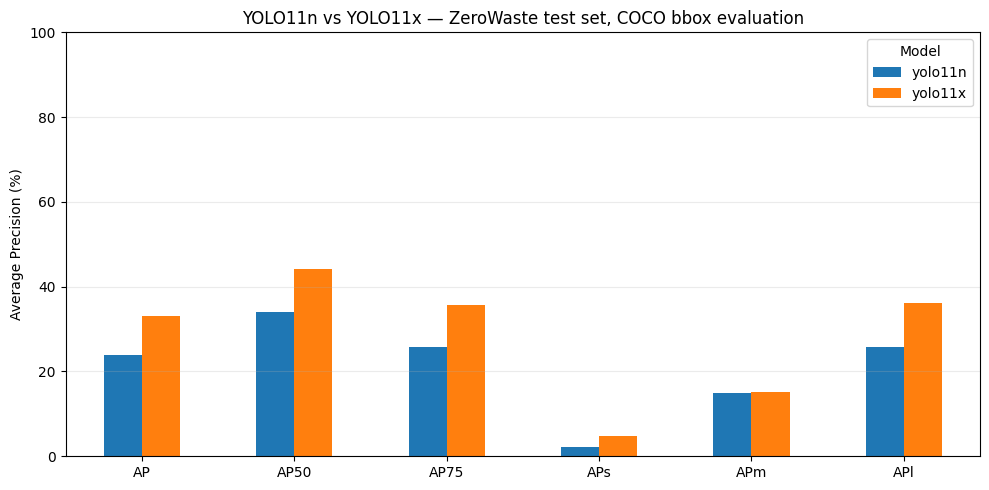

Selisih YOLO11x − YOLO11n (percentage points):


,delta_pp
AP,9.192
AP50,9.957
AP75,9.886
APs,2.685
APm,0.181
APl,10.388


AP tertinggi pada eksperimen ini: yolo11x
Interpretasikan APs/APm/APl, biaya model, dan durasi training bersama-sama.


In [15]:
axis = comparison.loc[MODELS, METRICS].T.plot.bar(figsize=(10, 5), ylim=(0, 100), rot=0)
axis.set_ylabel('Average Precision (%)')
axis.set_title('YOLO11n vs YOLO11x — ZeroWaste test set, COCO bbox evaluation')
axis.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT / 'comparison.png', dpi=180)
plt.show()
delta = comparison.loc['yolo11x', METRICS] - comparison.loc['yolo11n', METRICS]
print('Selisih YOLO11x − YOLO11n (percentage points):')
display(delta.round(3).to_frame('delta_pp'))
if comparison['AP'].notna().all():
    print('AP tertinggi pada eksperimen ini:', comparison.loc[MODELS, 'AP'].idxmax())
print('Interpretasikan APs/APm/APl, biaya model, dan durasi training bersama-sama.')


### Perbandingan eksperimen dengan Table I paper
Kolom Source membedakan angka yang dilaporkan penulis dari hasil yang dihitung
notebook ini. Epoch ditampilkan agar perbedaan budget terlihat. Selisih terhadap
YOLOv7 dilaporkan sebagai percentage points; selisih tersebut tidak membuktikan
keunggulan arsitektur semata karena protokol training berbeda.


,Model,Source,Epochs,AP,AP50,AP75,APs,APm,APl
0,YOLOv3,Paper — Table I (reported),300,22.000,34.100,23.400,1.600,9.600,23.600
1,YOLOv4,Paper — Table I (reported),300,22.400,32.900,24.500,0.700,0.740,24.400
2,YOLOv5s,Paper — Table I (reported),300,25.300,36.100,27.600,4.700,14.700,27.000
3,YOLOv7,Paper — Table I (reported),300,33.200,44.300,35.000,5.900,20.000,35.600
4,YOLOF,Paper — Table I (reported),300,26.200,41.500,28.600,1.400,10.800,28.600
5,yolo11n,This notebook — measured on test set,30,23.950,34.129,25.767,2.079,14.876,25.725
6,yolo11x,This notebook — measured on test set,30,33.142,44.086,35.654,4.764,15.057,36.114


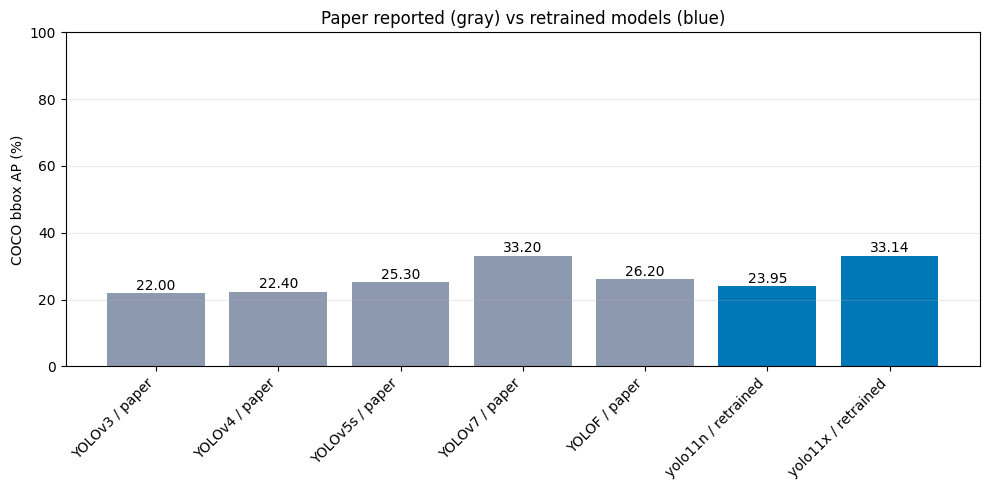

,AP,AP50,AP75,APs,APm,APl
Model vs paper YOLOv7 (delta pp),,,,,,
yolo11n,-9.249842,-10.170929,-9.232833,-3.820792,-5.123691,-9.87454
yolo11x,-0.058177,-0.213913,0.653662,-1.13586,-4.942673,0.513879


Paper: 300 epoch | Eksperimen notebook: 30 epoch.
Perbandingan hasil terlapor; protokol training berbeda dan model lama dilatih ulang dengan adapter upstream.


In [16]:
our_results = comparison.reset_index()[['Model'] + METRICS].copy()
our_results['Source'] = 'This notebook — measured on test set'
our_results['Epochs'] = EPOCHS
paper_comparison = pd.concat([paper_results, our_results], ignore_index=True)
paper_comparison = paper_comparison[['Model', 'Source', 'Epochs'] + METRICS]
display(paper_comparison.round(3))
paper_comparison.to_csv(REPORT / 'comparison_with_paper.csv', index=False)

fig, axis = plt.subplots(figsize=(10, 5))
colors = ['#8d99ae'] * len(paper_results) + ['#0077b6'] * len(our_results)
positions = np.arange(len(paper_comparison))
axis.bar(positions, paper_comparison['AP'], color=colors)
labels = [str(row.Model) + (' / paper' if idx < len(paper_results) else ' / retrained') for idx, row in paper_comparison.iterrows()]
axis.set_xticks(positions, labels, rotation=45, ha='right')
axis.set_ylabel('COCO bbox AP (%)')
axis.set_ylim(0, 100)
axis.set_title('Paper reported (gray) vs retrained models (blue)')
axis.grid(axis='y', alpha=0.25)
for idx, value in enumerate(paper_comparison['AP']):
    if pd.notna(value):
        axis.text(idx, value + 1, f'{value:.2f}', ha='center')
plt.tight_layout()
plt.savefig(REPORT / 'comparison_with_paper.png', dpi=180)
plt.show()

yolov7_reference = paper_results.set_index('Model').loc['YOLOv7', METRICS]
delta_paper = comparison[METRICS].subtract(yolov7_reference, axis='columns')
display(delta_paper.round(3).rename_axis('Model vs paper YOLOv7 (delta pp)'))
delta_paper.to_csv(REPORT / 'delta_vs_paper_yolov7.csv')
print(f'Paper: 300 epoch | Eksperimen notebook: {EPOCHS} epoch.')
print('Perbandingan hasil terlapor; protokol training berbeda dan model lama dilatih ulang dengan adapter upstream.')


## 10. Bandingkan prediksi pada gambar yang sama
Tiga gambar dipilih secara tetap dari test set. Confidence visualisasi 0.25
hanya untuk keterbacaan; evaluasi AP sebelumnya tetap memakai 0.001.
Ketujuh model memakai hasil prediksi COCO yang sudah diekspor.


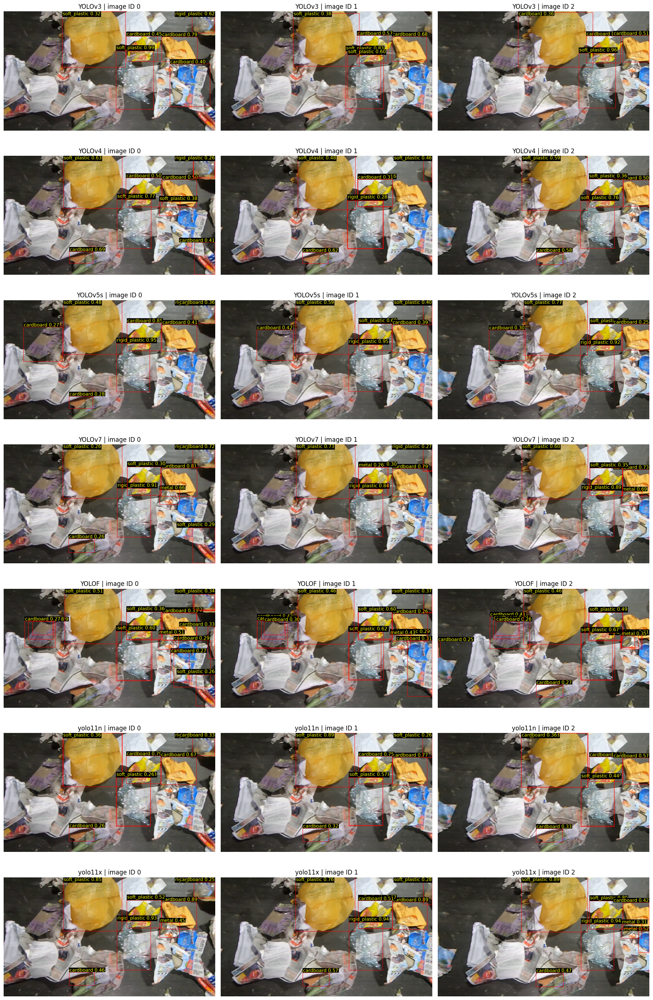

In [23]:
sample_ids = sorted(image_paths['test'])[:3]
all_models = LEGACY_MODELS + MODELS
font_path = font_manager.findfont('DejaVu Sans')

fig, axes = plt.subplots(
    len(all_models), len(sample_ids),
    figsize=(18, 4 * len(all_models)),
    squeeze=False,
)

category_names = {
    c['id']: c['name']
    for c in split_annotations['test']['categories']
}

for row_idx, model_name in enumerate(all_models):
    predictions = json.loads(
        (REPORT / f'{model_name}_predictions.json').read_text()
    )

    by_image = defaultdict(list)
    for prediction in predictions:
        if prediction['score'] >= 0.25:
            by_image[prediction['image_id']].append(prediction)

    for col_idx, image_id in enumerate(sample_ids):
        canvas = Image.open(
            image_paths['test'][image_id]
        ).convert('RGB')
        draw = ImageDraw.Draw(canvas)
        width, height = canvas.size

        font = ImageFont.truetype(
            font_path, size=max(18, int(width / 45))
        )

        for prediction in by_image[image_id]:
            x, y, bw, bh = prediction['bbox']
            draw.rectangle(
                [x, y, x + bw, y + bh],
                outline='red',
                width=3,
            )

            label = (
                f"{category_names[prediction['category_id']]} "
                f"{prediction['score']:.2f}"
            )

            # Ukur teks dan jaga agar label tetap di dalam gambar.
            bounds = draw.textbbox((0, 0), label, font=font)
            text_width = bounds[2] - bounds[0]
            text_height = bounds[3] - bounds[1]
            padding = 4

            tx = max(0, min(x, width - text_width - 2 * padding))
            ty = max(
                0,
                min(
                    y - text_height - 2 * padding,
                    height - text_height - 2 * padding,
                ),
            )

            draw.rectangle(
                [
                    tx, ty,
                    tx + text_width + 2 * padding,
                    ty + text_height + 2 * padding,
                ],
                fill='black',
            )
            draw.text(
                (
                    tx + padding - bounds[0],
                    ty + padding - bounds[1],
                ),
                label,
                font=font,
                fill='yellow',
            )

        axes[row_idx, col_idx].imshow(canvas)
        axes[row_idx, col_idx].set_title(
            f'{model_name} | image ID {image_id}'
        )
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig(
    REPORT / 'prediction_comparison.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## 11. Simpan dan download hasil
Arsip mencakup tabel CSV, prediksi JSON, grafik, manifest, log training,
konfigurasi dan best weights ketujuh model. Dataset dan last.pt tidak dimasukkan
agar ukuran arsip lebih kecil. Download lewat link hasil cell ini atau panel Files.
Notebook sendiri disimpan melalui File → Download → Download .ipynb setelah semua
cell selesai agar output notebook ikut tersimpan. Folder /content bersifat sementara; hasil permanen berada di Drive.

Dataset, ZIP, report, dan semua checkpoint tetap tersimpan di Drive.



PERBANDINGAN PAPER DAN HASIL KITA:


,Model,Source,Epochs,AP,AP50,AP75,APs,APm,APl
0,YOLOv3,Paper — Table I (reported),300,22.000,34.100,23.400,1.600,9.600,23.600
1,YOLOv3,Eksperimen kita — measured on test set,30,16.244,30.569,15.361,0.163,11.431,17.405
2,YOLOv4,Paper — Table I (reported),300,22.400,32.900,24.500,0.700,0.740,24.400
3,YOLOv4,Eksperimen kita — measured on test set,30,23.245,34.735,25.596,0.545,16.969,24.543
4,YOLOv5s,Paper — Table I (reported),300,25.300,36.100,27.600,4.700,14.700,27.000
5,YOLOv5s,Eksperimen kita — measured on test set,30,27.248,39.366,29.929,1.434,14.092,29.310
6,YOLOv7,Paper — Table I (reported),300,33.200,44.300,35.000,5.900,20.000,35.600
7,YOLOv7,Eksperimen kita — measured on test set,30,34.676,47.300,37.328,4.021,20.311,37.556
8,YOLOF,Paper — Table I (reported),300,26.200,41.500,28.600,1.400,10.800,28.600
9,YOLOF,Eksperimen kita — measured on test set,30,30.909,44.716,35.686,7.277,19.421,33.221


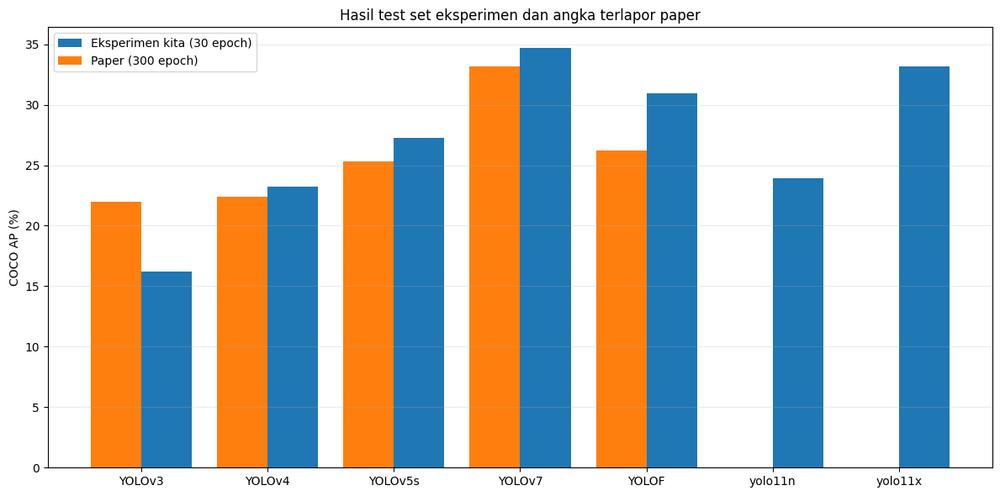

Arsip hasil: /content/drive/MyDrive/ZeroWaste/experiments/paper_plus_yolo11_v1/zerowaste_all_models_results.zip | MB: 1171.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import zipfile
from google.colab import files

REPORT.mkdir(parents=True, exist_ok=True)

model_order = [
    "YOLOv3", "YOLOv4", "YOLOv5s", "YOLOv7", "YOLOF",
    "yolo11n", "yolo11x",
]
metric_names = ["AP", "AP50", "AP75", "APs", "APm", "APl"]

# Angka yang dilaporkan di Table I paper.
paper_table = pd.DataFrame([
    ["YOLOv3", 22.0, 34.1, 23.4, 1.6, 9.6, 23.6],
    ["YOLOv4", 22.4, 32.9, 24.5, 0.7, 0.74, 24.4],
    ["YOLOv5s", 25.3, 36.1, 27.6, 4.7, 14.7, 27.0],
    ["YOLOv7", 33.2, 44.3, 35.0, 5.9, 20.0, 35.6],
    ["YOLOF", 26.2, 41.5, 28.6, 1.4, 10.8, 28.6],
], columns=["Model", *metric_names])
paper_table["Source"] = "Paper — Table I (reported)"
paper_table["Epochs"] = 300

# Ambil hasil eksperimen dari statistik COCO.
# Model lama yang belum dievaluasi akan dievaluasi sekarang.
our_rows = []
missing = {}

for model_name in model_order:
    stats_file = REPORT / f"{model_name}_coco_stats.json"

    try:
        if (
            not stats_file.exists()
            and model_name in LEGACY_MODELS
        ):
            print(f"Evaluasi test set: {model_name}", flush=True)
            result = evaluate_saved_legacy(model_name)
            if result is None:
                raise RuntimeError("Checkpoint belum tersedia.")

        if stats_file.exists():
            stats = json.loads(stats_file.read_text())
            if len(stats) < 6:
                raise ValueError("Statistik COCO tidak lengkap.")

            metrics = {
                name: float(value) * 100 if value >= 0 else np.nan
                for name, value in zip(metric_names, stats[:6])
            }
        elif model_name in {"yolo11n", "yolo11x"}:
            # Gunakan tabel evaluasi YOLO11 yang sudah dibuat notebook.
            results = globals().get("our_results")
            if results is None:
                raise RuntimeError("Hasil evaluasi YOLO11 belum tersedia.")

            matched = results.loc[results["Model"] == model_name]
            if len(matched) != 1:
                raise RuntimeError("Hasil evaluasi model tidak ditemukan/ambigu.")

            metrics = {
                name: float(matched.iloc[0][name])
                for name in metric_names
            }
        else:
            raise FileNotFoundError(stats_file)

        our_rows.append(dict(
            Model=model_name,
            Source="Eksperimen kita — measured on test set",
            Epochs=int(EPOCHS),
            **metrics,
        ))

    except Exception as error:
        missing[model_name] = str(error)

if missing:
    for model_name, error in missing.items():
        print(f"BELUM LENGKAP — {model_name}: {error}")
    raise RuntimeError(
        "ZIP belum dibuat. Selesaikan evaluasi model di atas, "
        "lalu jalankan ulang cell ini."
    )

columns = ["Model", "Source", "Epochs", *metric_names]
our_table = pd.DataFrame(our_rows)[columns]
paper_table = paper_table[columns]

comparison = pd.concat(
    [paper_table, our_table], ignore_index=True
)
comparison["_order"] = comparison["Model"].map(
    {name: i for i, name in enumerate(model_order)}
)
comparison = comparison.sort_values(
    ["_order", "Epochs"], ascending=[True, False]
).drop(columns="_order").reset_index(drop=True)

# Selisih hasil kita terhadap paper untuk model yang sama.
delta = our_table.merge(
    paper_table,
    on="Model",
    suffixes=("_ours", "_paper"),
)
delta_table = delta[["Model", "Epochs_ours", "Epochs_paper"]].copy()
for metric in metric_names:
    delta_table[f"{metric}_delta_pp"] = (
        delta[f"{metric}_ours"] - delta[f"{metric}_paper"]
    )

paper_table.to_csv(REPORT / "paper_table_I.csv", index=False)
our_table.to_csv(REPORT / "our_all_models_test_results.csv", index=False)
comparison.to_csv(REPORT / "all_models_vs_paper.csv", index=False)
delta_table.to_csv(REPORT / "same_model_delta_vs_paper.csv", index=False)

(REPORT / "all_models_vs_paper.json").write_text(
    comparison.to_json(orient="records", indent=2),
    encoding="utf-8",
)

print("\nPERBANDINGAN PAPER DAN HASIL KITA:")
display(comparison.round(3))

# Grafik AP: YOLO11 tidak memiliki angka referensi pada paper ini.
ours_by_model = our_table.set_index("Model")
paper_by_model = paper_table.set_index("Model")
x = np.arange(len(model_order))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x + 0.2,
    [ours_by_model.loc[name, "AP"] for name in model_order],
    width=0.4,
    label=f"Eksperimen kita ({EPOCHS} epoch)",
)
paper_positions = [
    i for i, name in enumerate(model_order)
    if name in paper_by_model.index
]
ax.bar(
    np.array(paper_positions) - 0.2,
    [
        paper_by_model.loc[model_order[i], "AP"]
        for i in paper_positions
    ],
    width=0.4,
    label="Paper (300 epoch)",
)
ax.set_xticks(x)
ax.set_xticklabels(model_order)
ax.set_ylabel("COCO AP (%)")
ax.set_title("Hasil test set eksperimen dan angka terlapor paper")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(REPORT / "all_models_vs_paper_AP.png", dpi=200)
plt.show()
plt.close(fig)

notes = f"""Perbandingan hasil ZeroWaste

Paper:
Empirical Study of Real-time One-Stage Object Detection Methods
on Recyclable Waste Dataset
DOI: 10.1109/RIVF55975.2022.10013902
Angka referensi berasal dari Table I; training 300 epoch.

Eksperimen kita:
YOLOv3, YOLOv4, YOLOv5s, YOLOv7, YOLOF, YOLO11n, YOLO11x.
Anggaran training: {EPOCHS} epoch per model.
Metrik hasil eksperimen berasal dari evaluasi test set.
Checkpoint terbaik dipilih berdasarkan validasi.

Perbedaan epoch dan konfigurasi harus dipertimbangkan:
tabel ini bukan reproduksi terkontrol seluruh protokol paper.
Delta dihitung sebagai hasil kita minus paper, dalam poin persentase.
Paper ini tidak melaporkan YOLO11n atau YOLO11x.
"""
(REPORT / "comparison_notes.txt").write_text(notes, encoding="utf-8")

# Gabungkan checkpoint model lama dan YOLO11.
all_weights = {}
all_weights.update(globals().get("legacy_weights", {}))
all_weights.update(globals().get("best_weights", {}))

missing_weights = [
    name for name in model_order
    if name not in all_weights or not Path(all_weights[name]).is_file()
]
if missing_weights:
    raise RuntimeError(
        f"Checkpoint belum dimuat untuk: {missing_weights}. "
        "ZIP belum dibuat."
    )

# Simpan notebook aktif secara manual dari menu File jika diperlukan.
# ZIP ini berisi laporan, tabel, grafik, konfigurasi, dan checkpoint.
RESULT_ZIP = PERSISTENT / "zerowaste_all_models_results.zip"
RESULT_ZIP.parent.mkdir(parents=True, exist_ok=True)
added = set()

with zipfile.ZipFile(
    RESULT_ZIP, "w", compression=zipfile.ZIP_DEFLATED
) as archive:

    def add_file(path, archive_name):
        path = Path(path)
        archive_name = Path(archive_name).as_posix()
        if path.is_file() and archive_name not in added:
            archive.write(path, archive_name)
            added.add(archive_name)

    for path in REPORT.rglob("*"):
        add_file(
            path,
            Path("report") / path.relative_to(REPORT),
        )

    add_file(DATA_YAML, "dataset/zerowaste.yaml")
    add_file(LEGACY_DATA_YAML, "dataset/zerowaste_legacy.yaml")

    for path in REFERENCE.rglob("*"):
        relative = path.relative_to(REFERENCE)
        if ".git" not in relative.parts:
            add_file(path, Path("github_reference") / relative)

    for model_name in model_order:
        best = Path(all_weights[model_name])
        run_dir = best.parent if best.suffix == ".pth" else best.parent.parent

        for path in run_dir.rglob("*"):
            if not path.is_file():
                continue
            if path.name in {"last.pt", "latest.pth"}:
                continue
            if path.suffix in {".pt", ".pth"} and path != best:
                continue

            add_file(
                path,
                Path("runs") / run_dir.name / path.relative_to(run_dir),
            )

print(
    "Arsip hasil:", RESULT_ZIP,
    "| MB:", round(RESULT_ZIP.stat().st_size / 1e6, 1),
)
files.download(str(RESULT_ZIP))

## Catatan laporan dan referensi
- Laporkan GPU, versi paket, seed, epoch, ukuran input dan batch dari manifest.
- AP/AP50/AP75/APs/APm/APl adalah bbox AP COCO, bukan akurasi klasifikasi.
- Validation digunakan untuk memilih best checkpoint, test untuk tabel akhir.
- Jangan mengisi hasil sebelum training/evaluasi selesai atau menyalin angka COCO
  pretraining sebagai hasil ZeroWaste. Hasil training 1 epoch hanya cek alur.
- APs: area < 32²; APm: area 32²–96²; APl: area > 96² (batas persis mengikuti COCO API).
- Jika runtime terputus, hasil /content dapat hilang. Checkpoint disimpan di Drive dan training dilanjutkan pada sesi berikutnya.

Sumber:
0. [Vo et al., RIVF 2022 — paper utama, Table I](https://doi.org/10.1109/RIVF55975.2022.10013902)
1. [ZeroWaste dataset resmi](https://github.com/dbash/zerowaste)
2. [ZeroWaste-f di Zenodo](https://zenodo.org/records/6412647)
3. [Dokumentasi YOLO11](https://docs.ultralytics.com/models/yolo11/)
4. [Training Ultralytics](https://docs.ultralytics.com/modes/train/)
5. [COCOeval resmi](https://github.com/cocodataset/cocoapi/blob/master/PythonAPI/pycocotools/cocoeval.py)

Notebook belum dieksekusi dengan GPU Colab saat dibuat; hasil eksperimen dihasilkan
oleh eksekusi pengguna, bukan angka contoh.

Training_hours mencatat durasi sesi training yang selesai terakhir; jika resume, angka ini tidak mencakup seluruh sesi sebelumnya.
